# An Ambiguous Arrangement of Dots

This notebook develops a controlled visual stimulus to study how the same spatial pattern can be perceived differently at fixation and in peripheral vision. The central goal is to obtain an image in which the dot lattice appears clear where gaze lands while becoming weaker or less structured away from fixation.

![Teaser image](../files/2026-07-31-pale-blue-dots.svg)

<!-- TEASER_END -->

This perceptual asymmetry is grounded in retinal physiology. Cone density is maximal in the foveal and parafoveal region and supports fine spatial sampling and color discrimination, whereas rod density dominates the peripheral retina and supports high sensitivity to luminance changes under broader pooling but with poorer chromatic and fine-form precision. Because of this organization, a single static image can look sharply segmented at fixation and more texture-like in the periphery.

A useful intuition is that the macular visual region corresponds to roughly the apparent size of a thumb seen at arm length. Inside that central zone, color and fine contour cues are sampled with high fidelity; outside it, feature integration grows coarser, crowding increases, and local dot structure is more likely to collapse perceptually.

The following sections explain the method step by step, then analyze each parameter sweep in terms of both image statistics and visual physiology.

### Method Step 1: Initialize Numerical Tools

This cell imports numerical utilities used throughout the notebook and configures readable numeric printing. The purpose is to keep all subsequent geometric and color computations explicit and reproducible.

In [1]:
import numpy as np
np.set_printoptions(precision=6, suppress=True)
import os

## Method: Building The Stimulus Step By Step

The method is organized as a sequence of implementation blocks. Each code cell introduces one technical layer, and each layer has a specific perceptual purpose. The progression goes from environment setup, to rendering infrastructure, to color and shape modeling, and finally to generation of a baseline stimulus that is later explored through one-parameter sweeps.

### Method Step 2: Install Rendering Dependency

This cell installs the Cairo backend used to rasterize and export the stimulus. Cairo provides precise vector-to-pixel control, which is essential when small contour and spacing differences are expected to produce perceptual effects.

In [2]:
%pip install pycairo

Note: you may need to restart the kernel to use updated packages.


### Method Step 3: Define Canvas Geometry

This cell imports rendering modules and defines image dimensions. The selected aspect ratio and scale determine the lattice footprint and therefore the eccentricity range over which central and peripheral processing can be compared.

In [3]:
import cairo
from IPython.display import Image, display
from math import pi
from io import BytesIO

N_height, N_width = int(1400/1.618), 1400
N_height, N_width

(865, 1400)

### Method Step 4: Create Display and Export Utilities

This cell defines helper functions for on-screen visualization and file export. The goal is to keep stimulus generation and result inspection tightly coupled so that parameter changes can be interpreted immediately.

In [4]:
def disp(draw_func):
    surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, N_width, N_height)
    ctx = cairo.Context(surface)
    draw_func(ctx, N_height=N_height, N_width=N_width)
    with BytesIO() as fileobj:
        surface.write_to_png(fileobj)
        display(Image(fileobj.getvalue(), width=N_width))

def render_pdf(draw_func, savepath):
    with cairo.PDFSurface(f"{savepath}.pdf", N_width, N_height) as surface:
        ctx = cairo.Context(surface)
        draw_func(ctx, N_height=N_height, N_width=N_width)        

def render_svg(draw_func, savepath):
    with cairo.SVGSurface(f"{savepath}.svg", N_width, N_height) as surface:
        ctx = cairo.Context(surface)
        draw_func(ctx, N_height=N_height, N_width=N_width)        

figpath = '../files'
%mkdir -p {figpath}
import numpy as np
np.set_printoptions(precision=2, suppress=True)

import os
from IPython import get_ipython
ip = get_ipython()
# print(ip.user_ns)
study_name = None
if '__vsc_ipynb_file__' in ip.user_ns:
    # https://github.com/msm1089/ipynbname/issues/17
    study_name = os.path.split(os.path.basename(ip.user_ns['__vsc_ipynb_file__']))[1]
elif '__file__' in ip.user_ns:
    study_name = ip.user_ns['__file__']#.replace('.ipynb', '')
else:
    import ipynbname
    study_name = ipynbname.name()

savepath = os.path.join(figpath, study_name.replace('.ipynb', ''))
print(f'{savepath=}')

savepath='../files/2026-07-31-pale-blue-dots'


### Method Step 5: Build a Controlled Color Mapping

This cell defines how one can manipulate hue and saturation while controlling luminance. Isoluminant-like control is important because rods and cones differ in spectral and spatial behavior, and we want to manipulate chromatic cues without introducing large luminance confounds.

The approximate peak sensitivity wavelengths for human cone types are:

* S cones (short - blueish): ~420 nm
* M cones (medium - greenish): ~530 nm
* L cones (long - reddish): ~560 nm

These peaks correspond to the absorption maxima of the photopsins in each cone type. The actual sensitivity curves overlap significantly, spanning roughly:

* S: 400–500 nm
* M: 450–630 nm
* L: 500–700 nm

![Human cone sensitivity curves](https://github.com/laurentperrinet/lambda2color/raw/main/cmf.png)


In [5]:
def xyz_from_xy(x_value: float, y_value: float) -> np.ndarray:
    """Return the vector (x, y, 1-x-y)."""
    return np.array((x_value, y_value, 1 - x_value - y_value))


class Lambda2color:
    """A class representing a colour system.

    A colour system defined by the CIE x, y and z=1-x-y coordinates of
    its three primary illuminants and its "white point".

    """

    def __init__(
        self, red: np.ndarray, green: np.ndarray, blue: np.ndarray, white: np.ndarray):
        """Initialise the ColourSystem object.

        Pass vectors (ie NumPy arrays of shape (3,)) for each of the
        red, green, blue  chromaticities and the white illuminant
        defining the colour system.

        """
        # Chromaticities
        self.red, self.green, self.blue = red, green, blue
        self.white = white
        # The chromaticity matrix (rgb -> xyz) and its inverse
        self.chromaticity_matrix = np.vstack((self.red, self.green, self.blue)).T
        self.inv_chromaticity_matrix = np.linalg.inv(self.chromaticity_matrix)
        # White scaling array
        self.wscale = self.inv_chromaticity_matrix.dot(self.white)

        # xyz -> rgb transformation matrix
        self.transformation_matrix = self.inv_chromaticity_matrix / self.wscale[:, np.newaxis]

        # the CIE colour matching function for 380 - 780 nm in 5 nm intervals
        cmf_str = """380 0.0014 0.0000 0.0065
        385 0.0022 0.0001 0.0105
        390 0.0042 0.0001 0.0201
        395 0.0076 0.0002 0.0362
        400 0.0143 0.0004 0.0679
        405 0.0232 0.0006 0.1102
        410 0.0435 0.0012 0.2074
        415 0.0776 0.0022 0.3713
        420 0.1344 0.0040 0.6456
        425 0.2148 0.0073 1.0391
        430 0.2839 0.0116 1.3856
        435 0.3285 0.0168 1.6230
        440 0.3483 0.0230 1.7471
        445 0.3481 0.0298 1.7826
        450 0.3362 0.0380 1.7721
        455 0.3187 0.0480 1.7441
        460 0.2908 0.0600 1.6692
        465 0.2511 0.0739 1.5281
        470 0.1954 0.0910 1.2876
        475 0.1421 0.1126 1.0419
        480 0.0956 0.1390 0.8130
        485 0.0580 0.1693 0.6162
        490 0.0320 0.2080 0.4652
        495 0.0147 0.2586 0.3533
        500 0.0049 0.3230 0.2720
        505 0.0024 0.4073 0.2123
        510 0.0093 0.5030 0.1582
        515 0.0291 0.6082 0.1117
        520 0.0633 0.7100 0.0782
        525 0.1096 0.7932 0.0573
        530 0.1655 0.8620 0.0422
        535 0.2257 0.9149 0.0298
        540 0.2904 0.9540 0.0203
        545 0.3597 0.9803 0.0134
        550 0.4334 0.9950 0.0087
        555 0.5121 1.0000 0.0057
        560 0.5945 0.9950 0.0039
        565 0.6784 0.9786 0.0027
        570 0.7621 0.9520 0.0021
        575 0.8425 0.9154 0.0018
        580 0.9163 0.8700 0.0017
        585 0.9786 0.8163 0.0014
        590 1.0263 0.7570 0.0011
        595 1.0567 0.6949 0.0010
        600 1.0622 0.6310 0.0008
        605 1.0456 0.5668 0.0006
        610 1.0026 0.5030 0.0003
        615 0.9384 0.4412 0.0002
        620 0.8544 0.3810 0.0002
        625 0.7514 0.3210 0.0001
        630 0.6424 0.2650 0.0000
        635 0.5419 0.2170 0.0000
        640 0.4479 0.1750 0.0000
        645 0.3608 0.1382 0.0000
        650 0.2835 0.1070 0.0000
        655 0.2187 0.0816 0.0000
        660 0.1649 0.0610 0.0000
        665 0.1212 0.0446 0.0000
        670 0.0874 0.0320 0.0000
        675 0.0636 0.0232 0.0000
        680 0.0468 0.0170 0.0000
        685 0.0329 0.0119 0.0000
        690 0.0227 0.0082 0.0000
        695 0.0158 0.0057 0.0000
        700 0.0114 0.0041 0.0000
        705 0.0081 0.0029 0.0000
        710 0.0058 0.0021 0.0000
        715 0.0041 0.0015 0.0000
        720 0.0029 0.0010 0.0000
        725 0.0020 0.0007 0.0000
        730 0.0014 0.0005 0.0000
        735 0.0010 0.0004 0.0000
        740 0.0007 0.0002 0.0000
        745 0.0005 0.0002 0.0000
        750 0.0003 0.0001 0.0000
        755 0.0002 0.0001 0.0000
        760 0.0002 0.0001 0.0000
        765 0.0001 0.0000 0.0000
        770 0.0001 0.0000 0.0000
        775 0.0001 0.0000 0.0000
        780 0.0000 0.0000 0.0000"""
        cmf = np.zeros((len(cmf_str.split("\n")), 4))
        for i, line in enumerate(cmf_str.split("\n")):
            cmf[i, :] = np.fromstring(line, sep=" ")
        self.cmf = cmf

    def xyz_to_rgb(self, xyz: np.ndarray) -> np.ndarray:
        """Transform from xyz to rgb representation of colour.

        The output rgb components are normalized on their maximum
        value. If xyz is out the rgb gamut, it is desaturated until it
        comes into gamut.

        Fractional rgb components are returned.

        """
        rgb = np.tensordot(xyz, self.transformation_matrix.T, axes=1)

        if np.any(rgb < 0):
            # We're not in the RGB gamut: approximate by desaturating
            rgb -= np.min(rgb)
        if not np.all(rgb == 0):
            # Normalize the rgb vector
            rgb /= np.max(rgb)
        return rgb

    def spec_to_xyz(self, spec) -> np.ndarray:
        """Convert a spectrum to an xyz point.

        The last dimension of the spectrum *must* be on the same grid of
        points as the colour-matching function self.cmf, that is,

                    380-780 nm in 5 nm steps.

        """
        if np.isscalar(spec):
            # Handle single wavelength input by creating a one-hot spectrum
            spec_array = np.zeros(len(self.cmf))
            idx = np.where(self.cmf[:, 0] == spec)[0]
            if idx.size > 0:
                spec_array[idx[0]] = 1.0
            else:
                # Wavelength not found in the 5nm grid, return zeros
                return np.zeros(3)
            spec = spec_array

        xyz = np.tensordot(spec, self.cmf[:, 1:], axes=1)
        den = np.sum(xyz)
        if den == 0.0:
            return xyz
        return xyz / den

    def spec_to_rgb(self, spec) -> np.ndarray:
        """Convert a spectrum to an rgb value.

        The last dimension of the spectrum *must* be on the same grid of
        points as the colour-matching function self.cmf, that is,

                    380-780 nm in 5 nm steps.

        """
        xyz = self.spec_to_xyz(spec)
        return self.xyz_to_rgb(xyz)


In [6]:


# # Define a standard white illuminant (D65)
# illuminant_D65 = xyz_from_xy(0.3127, 0.3291)

# # Initialize color space conversion for sRGB
# cs_srgb = Lambda2color(
#     red=xyz_from_xy(0.64, 0.33),
#     green=xyz_from_xy(0.30, 0.60),
#     blue=xyz_from_xy(0.15, 0.06),
#     white=illuminant_D65
# )

# # Convert wavelengths to RGB
# wavelengths = cs_srgb.cmf[1:, 0]
# N_wavelengths = len(wavelengths)
# hues = np.zeros((N_wavelengths, 3))
# for i_wavelength in range(N_wavelengths):
#     spec = np.zeros((N_wavelengths+1))
#     spec[i_wavelength] = 1
#     hues[i_wavelength, :] = cs_srgb.spec_to_rgb(spec)

# # give for S, M and L cones' peak sensitivities
# for spec, color in [(445, 'blue'), (555, 'green'), (600, 'red')]:
#   i_wavelength = np.argmin(np.abs(wavelengths - spec))
#   print(f' RGB for the {color=} at wavelength {wavelengths[i_wavelength]} nm: {hues[i_wavelength, :]}')

In [7]:
# a standard white:
illuminant_D65 = xyz_from_xy(0.3127, 0.3291)
# color conversion class
cs_srgb = Lambda2color(red=xyz_from_xy(0.64, 0.33),
                       green=xyz_from_xy(0.30, 0.60),
                       blue=xyz_from_xy(0.15, 0.06),
                       white=illuminant_D65)


In [8]:
wavelengths = cs_srgb.cmf[1:, 0]
wavelengths, wavelengths.shape


(array([385., 390., 395., 400., 405., 410., 415., 420., 425., 430., 435.,
        440., 445., 450., 455., 460., 465., 470., 475., 480., 485., 490.,
        495., 500., 505., 510., 515., 520., 525., 530., 535., 540., 545.,
        550., 555., 560., 565., 570., 575., 580., 585., 590., 595., 600.,
        605., 610., 615., 620., 625., 630., 635., 640., 645., 650., 655.,
        660., 665., 670., 675., 680., 685., 690., 695., 700., 705., 710.,
        715., 720., 725., 730., 735., 740., 745., 750., 755., 760., 765.,
        770., 775., 780.]),
 (80,))

In [9]:
N_wavelengths = len(wavelengths)
hues = np.zeros((N_wavelengths, 3))
for i_wavelength in range(N_wavelengths):
    spec = np.zeros((N_wavelengths+1))
    spec[i_wavelength] = 1
    hues[i_wavelength, :] = cs_srgb.spec_to_rgb(spec)
hues.shape

(80, 3)

In [10]:
i_wavelength = np.argmin(np.abs(wavelengths - 455))
i_wavelength, wavelengths[i_wavelength], hues[i_wavelength, :]

(np.int64(14), np.float64(455.0), array([0.16, 0.  , 1.  ]))

In [11]:
for spec, color in [(445, 'blue'), (555, 'green'), (600, 'red')]:
  i_wavelength = np.argmin(np.abs(wavelengths - spec))
  print(f' RGB for the {color=} at wavelength {wavelengths[i_wavelength]} nm: {hues[i_wavelength, :]}')

 RGB for the color='blue' at wavelength 445.0 nm: [0.21 0.   1.  ]
 RGB for the color='green' at wavelength 555.0 nm: [0.02 1.   0.  ]
 RGB for the color='red' at wavelength 600.0 nm: [1.   0.15 0.  ]


In [12]:
def get_spec(c_mean, c_std):
    """Return a spectrum corresponding to a Gaussian distribution of wavelengths.

    The mean wavelength is c_mean and the standard deviation is c_std.
    The output spectrum is normalized to have a maximum value of 1.

    """
    wavelengths = cs_srgb.cmf[:, 0]
    spec = np.exp(-0.5 * ((wavelengths - c_mean) / c_std) ** 2)
    spec /= np.sum(spec)
    return spec

In [13]:
spec = get_spec(455, 8)
spec, spec.shape

(array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.01, 0.04, 0.11, 0.21, 0.25, 0.21, 0.11, 0.04, 0.01, 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  ]),
 (81,))

In [14]:
cs_srgb.spec_to_rgb(spec)

array([0.11, 0.  , 1.  ])

### Method Step 6: Define Local Shape Primitives

This cell defines the local geometric primitive drawn at each lattice location. By switching between circles, diagonals, and polygons, the stimulus can vary orientation and corner energy, which changes how contours are grouped by the visual system.

In [15]:
def do_shape(cr, x, y, radius, shape_mode='circle', n_sides=6, angle0=0.0):
    """
    Draw either a circle or a regular polygon centered at (x, y).

    shape_mode: 'circle', 'polygon', or 'diagonal'
    n_sides: number of polygon sides when shape_mode='polygon'
    """
    rr = radius / 2.0

    if shape_mode == 'diagonal':
        # Diagonal mode = rotated square (diamond-like look).
        n_sides = 4
        angle0 = pi / 4

    if shape_mode in ('polygon', 'diagonal'):
        n_sides = int(max(3, n_sides))
        cr.new_sub_path()
        for k in range(n_sides):
            angle = angle0 + 2.0 * pi * k / n_sides
            px = x + rr * np.cos(angle)
            py = y + rr * np.sin(angle)
            if k == 0:
                cr.move_to(px, py)
            else:
                cr.line_to(px, py)
        cr.close_path()
    else:
        cr.save()
        cr.translate(x, y)
        cr.scale(rr, rr)
        cr.arc(0.0, 0.0, 1.0, 0.0, 2.0 * pi)
        cr.restore()


### Method Step 7: Generate the Hexagonal Lattice and Render the Field

This cell constructs the hexagonal arrangement by shifting alternating rows of a Cartesian mesh, computes dot attributes, paints the background, and draws all local shapes. This is the core of the stimulus synthesis pipeline and sets the spatial layout that interacts with eccentricity-dependent vision.

In [ ]:
def hexagonal_grid(cr, N_height, N_width, N_H, N_W, size_mag, c_mean, c_std, operator, shape_mode, n_sides):

    # Paint an explicit opaque background rectangle first.
    cr.save()
    cr.set_operator(cairo.OPERATOR_SOURCE)
    cr.rectangle(0, 0, N_width, N_height)
    spec = get_spec(c_ref, c_std)
    cr.set_source_rgb(*cs_srgb.spec_to_rgb(spec))
    cr.fill()
    cr.restore()

    cr.set_operator(operator)

    # Compute the grid
    # https://laurentperrinet.github.io/sciblog/posts/2020-04-16-creating-an-hexagonal-grid.html
    width_v, height_v = np.meshgrid(np.linspace(0, N_width, N_W+2, endpoint=True)[1:-1],
                                    np.linspace(0, N_height, N_H+2, endpoint=True)[1:-1], sparse=False, indexing='xy')

    width_v[::2, :] += N_width/N_W/4  # shift every second row by half a column
    width_v[1::2, :] -= N_width/N_W/4  # shift every second row by half a column

    # convert to cartesian coordinates
    X = width_v
    Y = height_v
    R = size_mag * N_height / N_H * np.ones_like(X)  # constant radius
    # C = (c_mean + c_std) * np.ones_like(X)  # incremented hue values
    C = c_mean  * np.ones_like(X)  # incremented hue values
    # C = c_mean + c_std * np.sign(np.random.randn(*X.shape))  # incremented hue values

    # draw
    for x, y, r, c in zip(X.ravel(), Y.ravel(), R.ravel(), C.ravel()):
        do_shape(cr, x, y, r, shape_mode=shape_mode, n_sides=n_sides)

        spec = get_spec(c, c_std)
        cr.set_source_rgb(*cs_srgb.spec_to_rgb(spec))
        cr.fill()

    return cr

## Results

This section reports the baseline output and then explores one parameter at a time. For each sweep, the interpretation follows a three-part structure: first what is changed, second how the code produces and displays the sweep, and third how the observed visual trend can be explained by perceptual physiology.

### Method Step 8: Set Lattice Density Regime

This cell selects the effective lattice density by defining the relation between image size and grid counts. Density tuning is crucial because peripheral pooling is strongly scale-dependent, and the illusion emerges only in a limited spacing regime.

In [17]:
N = 5
N = 8
N = 24
N = 35
N = 71
N = 20
N_H, N_W = int(N*N_height/N_width), N
N*N_height/N_width, N_H, N_W

(12.357142857142858, 12, 20)

### Method Step 9: Define a Baseline Parameter Set

This cell sets a baseline for hue, saturation, opacity, shape, and size before systematic scans. A stable baseline is required so that each subsequent sweep can be interpreted as the effect of one controlled change.

[0.11 0.   1.  ]


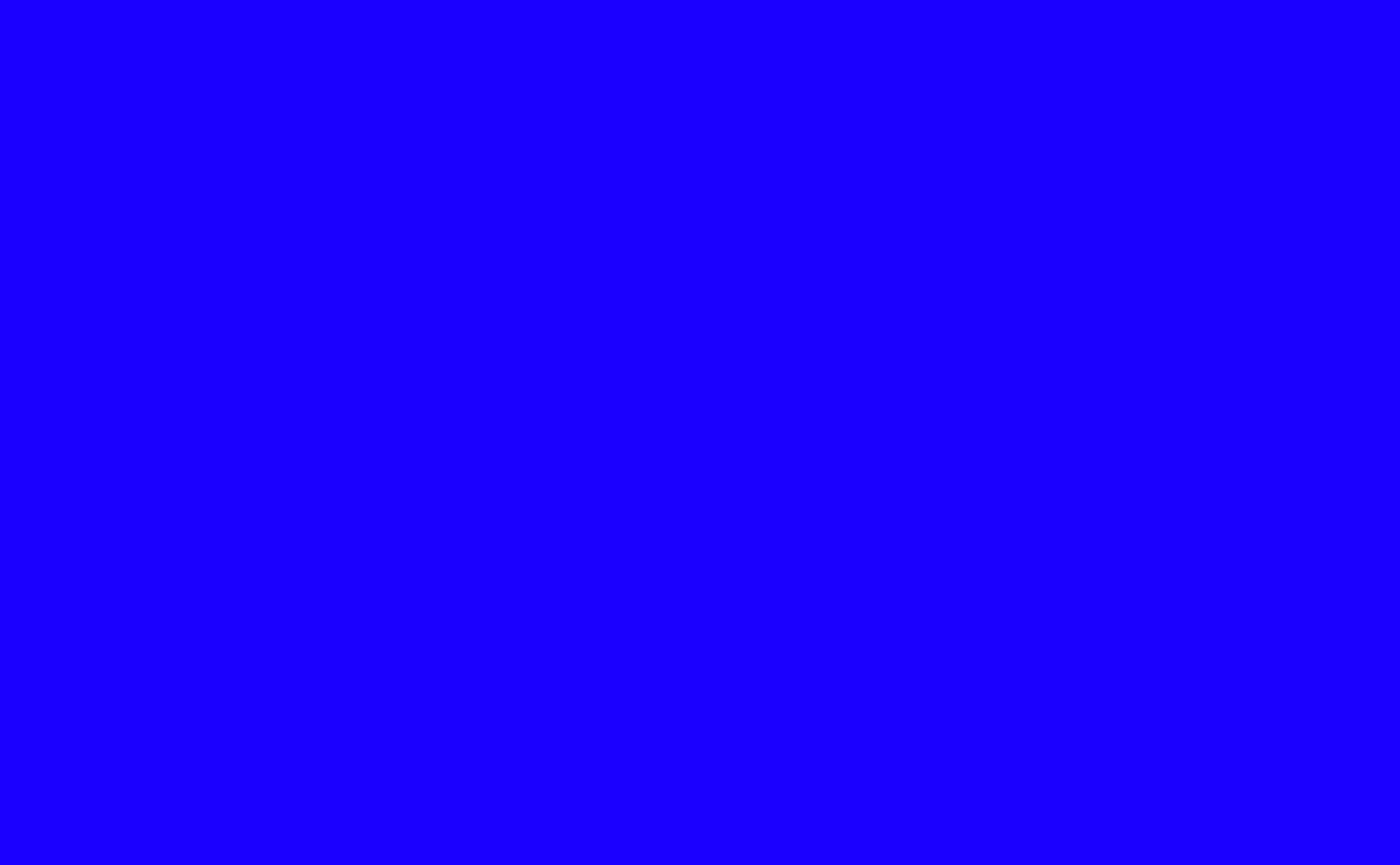

In [18]:
c_ref = 455
c_std = 8
opts = {"N_height": N_height, "N_width": N_width, # image size
        "N_H": N_H, "N_W": N_W, # grid size
        "shape_mode": 'circular', "n_sides": 6, # shapes
        "size_mag": .1618, # size of the shapes
        "c_mean": c_ref, "c_std": c_std, # mean and std of wavelengths
        "operator": cairo.OPERATOR_OVER, # blending mode
        }

@disp
def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts)

### Baseline Stimulus Interpretation

First, this stage defines the reference image that all later comparisons rely on, so no perceptual claim should be made without checking this baseline. Second, the associated code instantiates one fixed parameter vector and renders the corresponding field for inspection and export. Third, the expected visual pattern is a central region with clearer segmentation than the periphery, which is consistent with stronger cone-mediated color and fine-form sampling near the fovea and broader rod-dominated pooling at larger eccentricities.

In [19]:
def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts)
render_pdf(draw, savepath)
render_svg(draw, savepath)

[0.11 0.   1.  ]
[0.11 0.   1.  ]


## Parameter Sweeps

Each sweep modifies a single control variable while keeping the others fixed. This strategy isolates causal effects and makes the resulting perceptual transitions easier to interpret.

In [20]:
N_scan = 9

## size_mag

size_mag_=1.00e-01
[0.11 0.   1.  ]


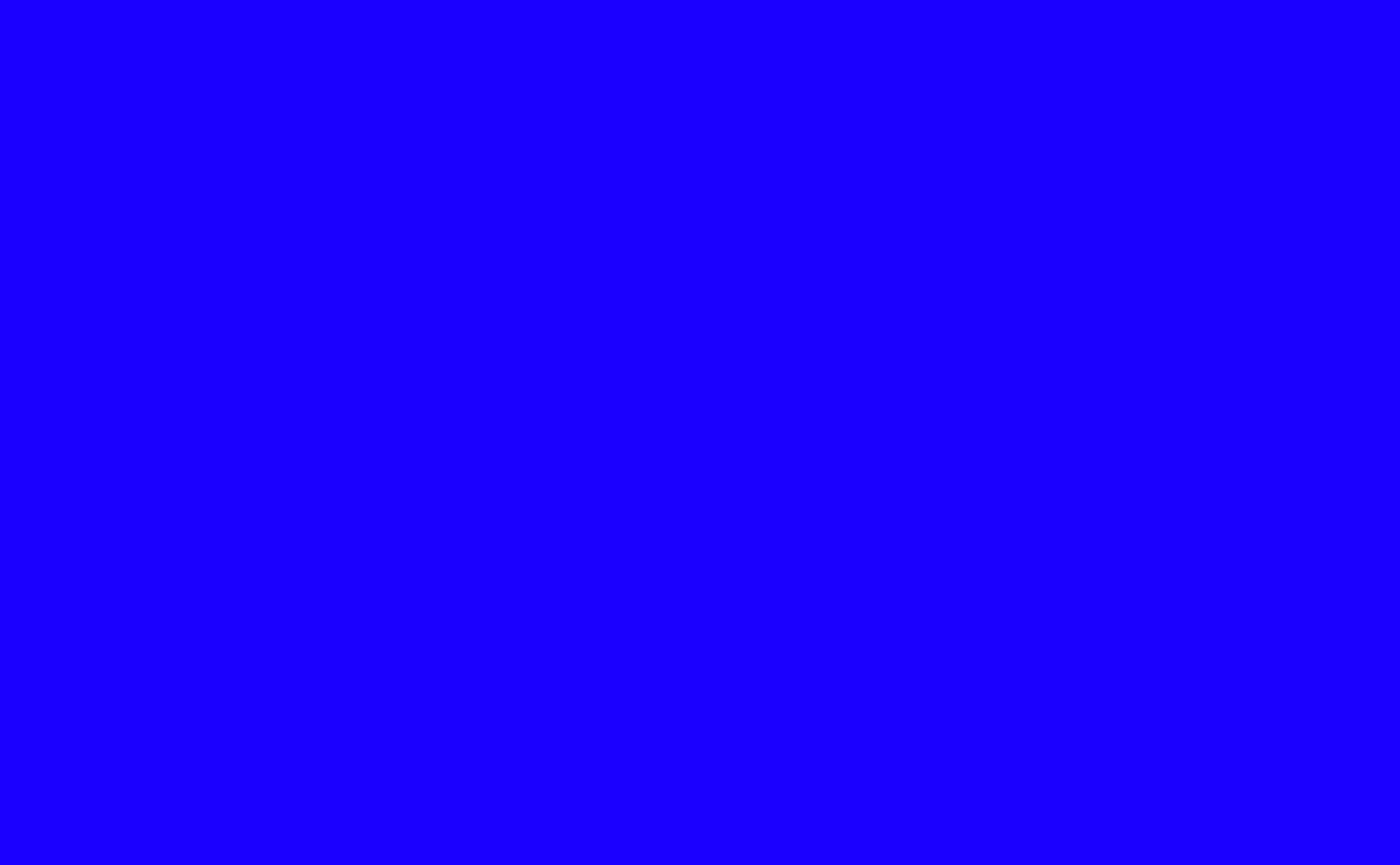

size_mag_=1.19e-01
[0.11 0.   1.  ]


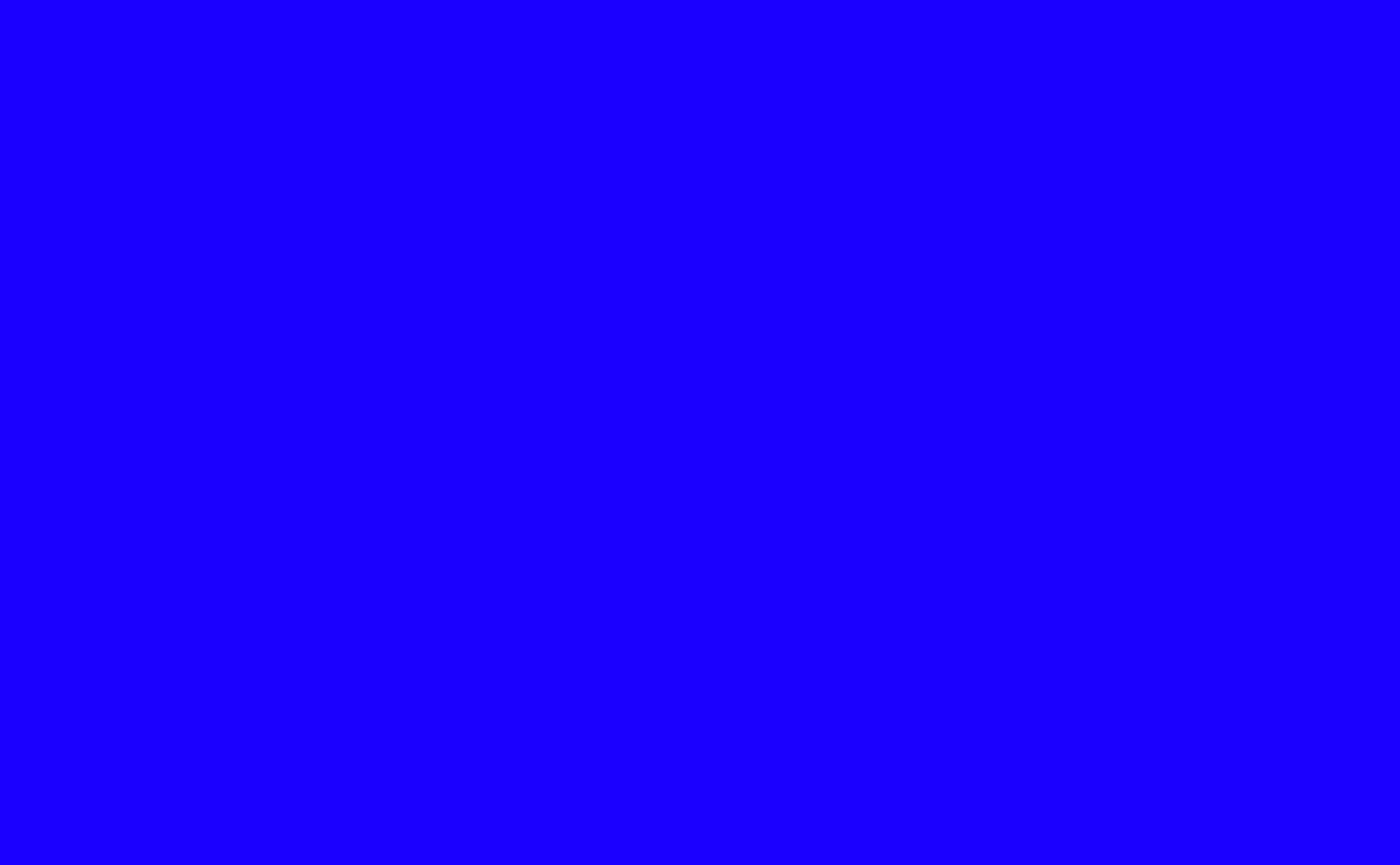

size_mag_=1.41e-01
[0.11 0.   1.  ]


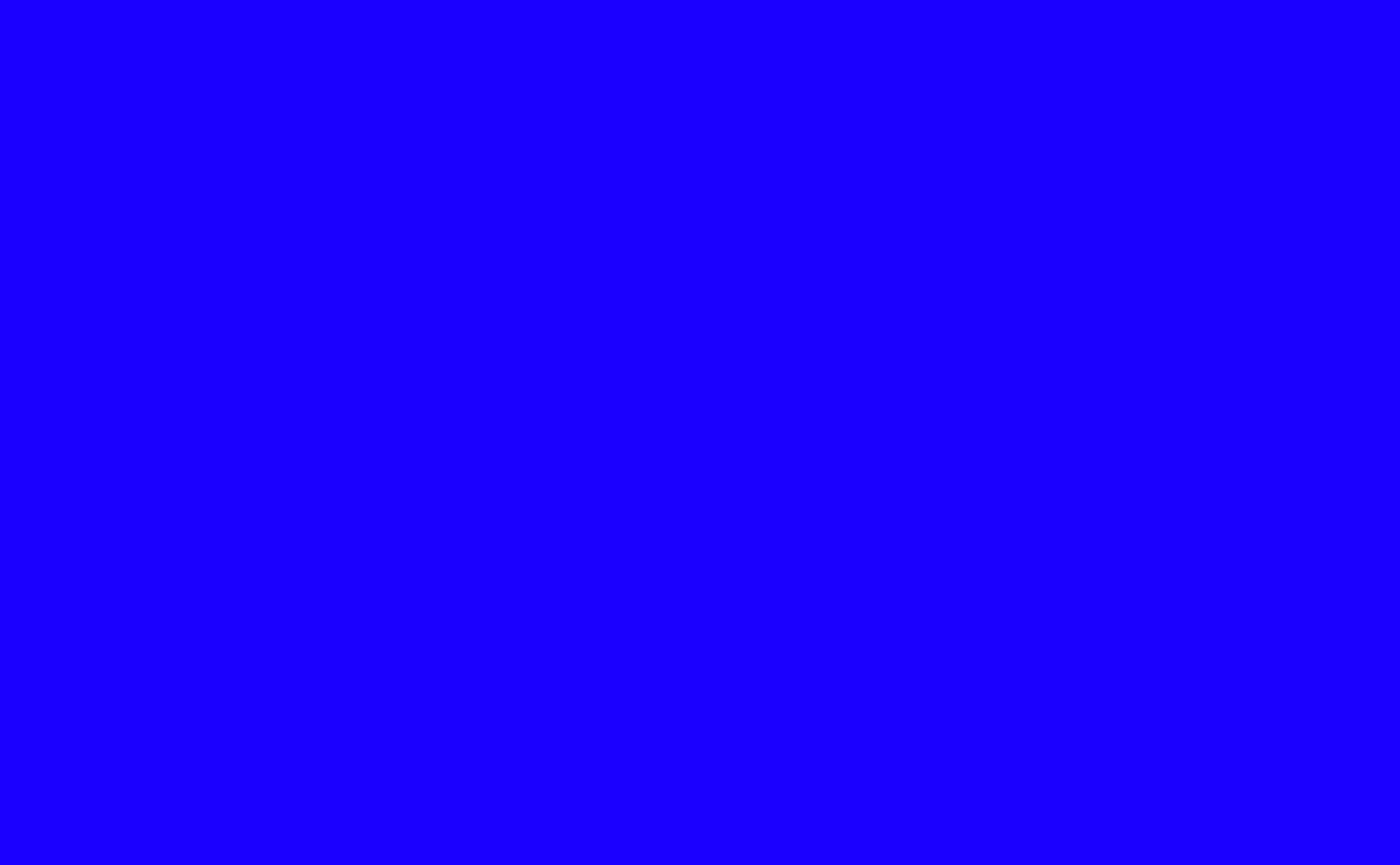

size_mag_=1.68e-01
[0.11 0.   1.  ]


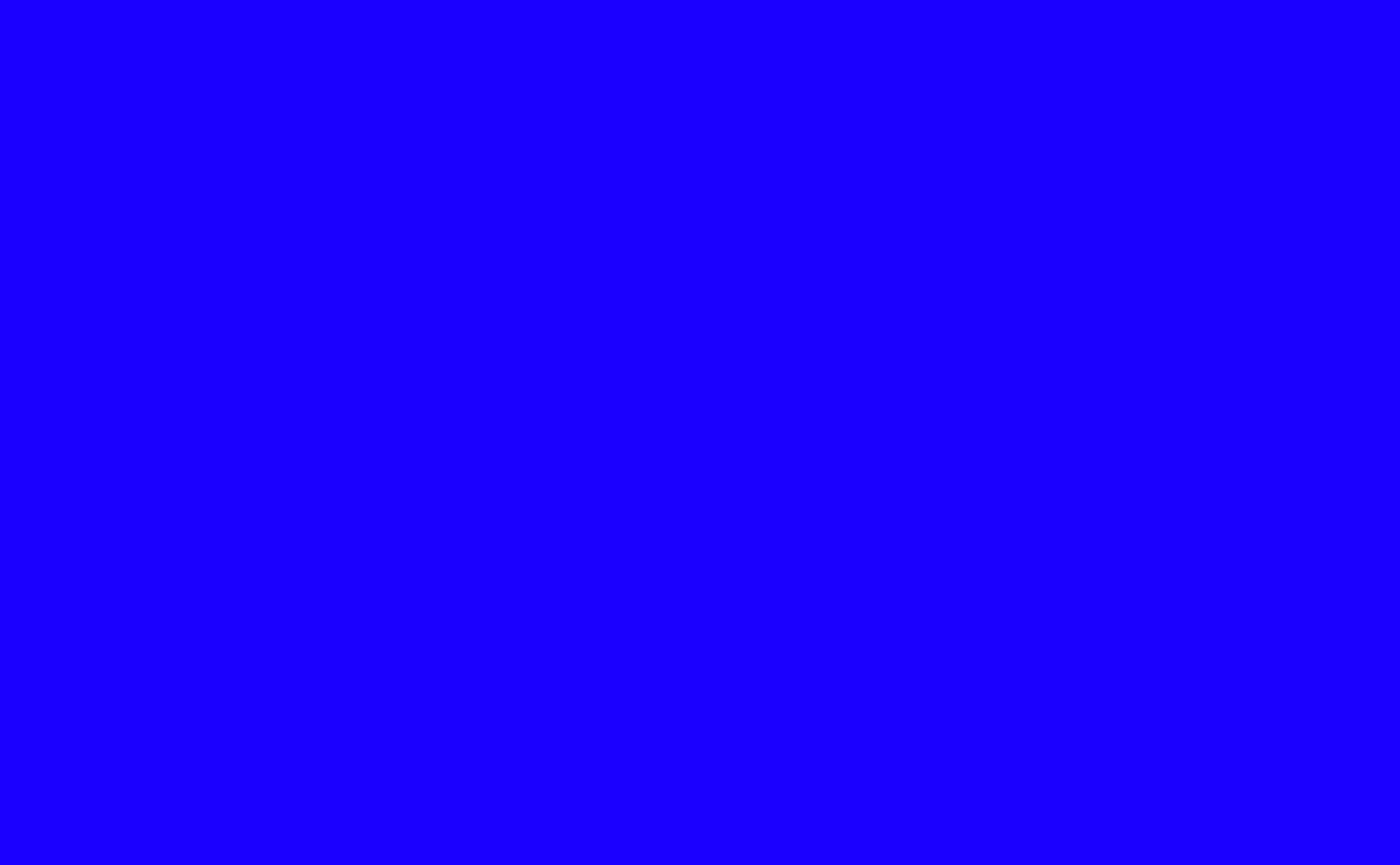

size_mag_=2.00e-01
[0.11 0.   1.  ]


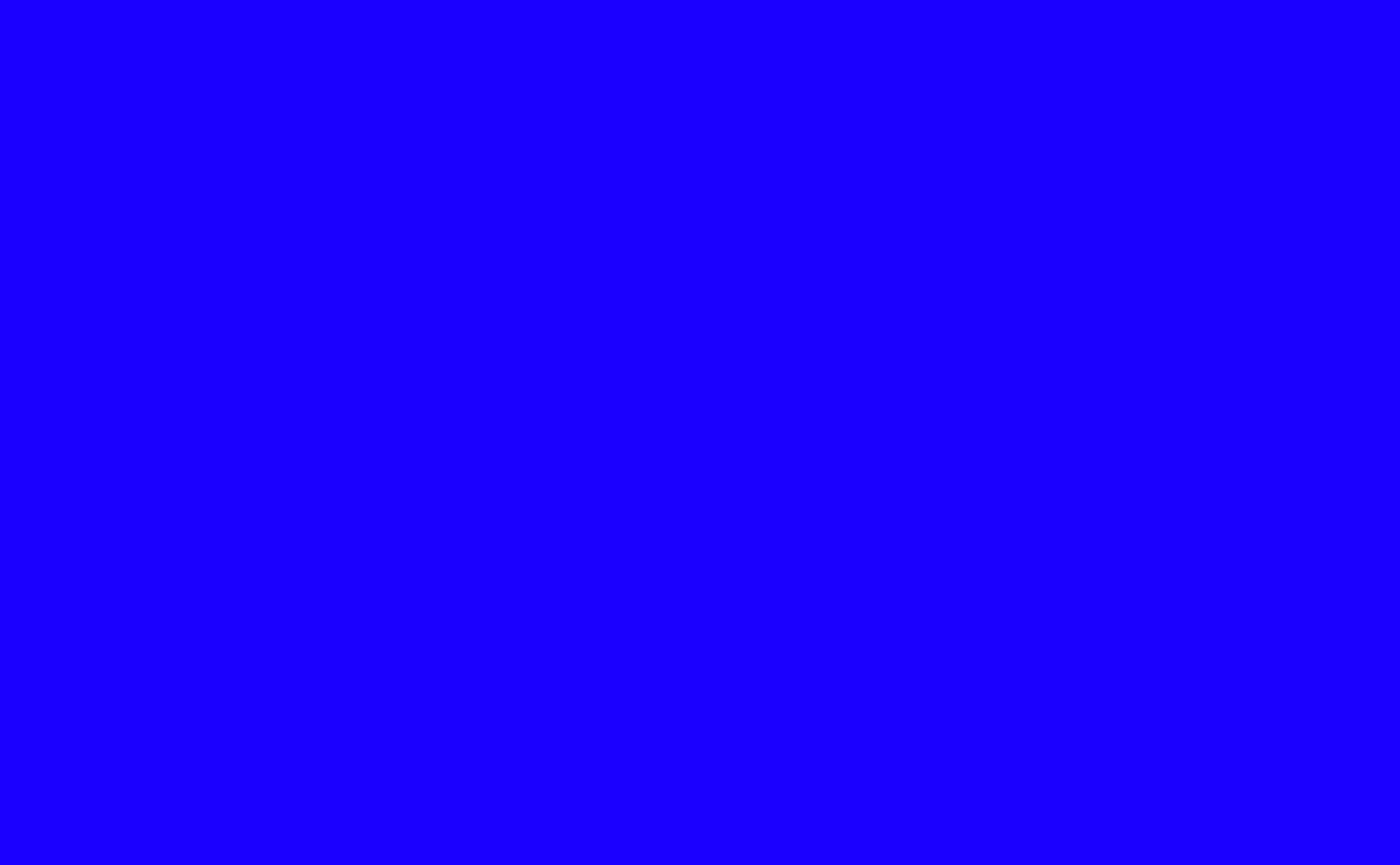

size_mag_=2.38e-01
[0.11 0.   1.  ]


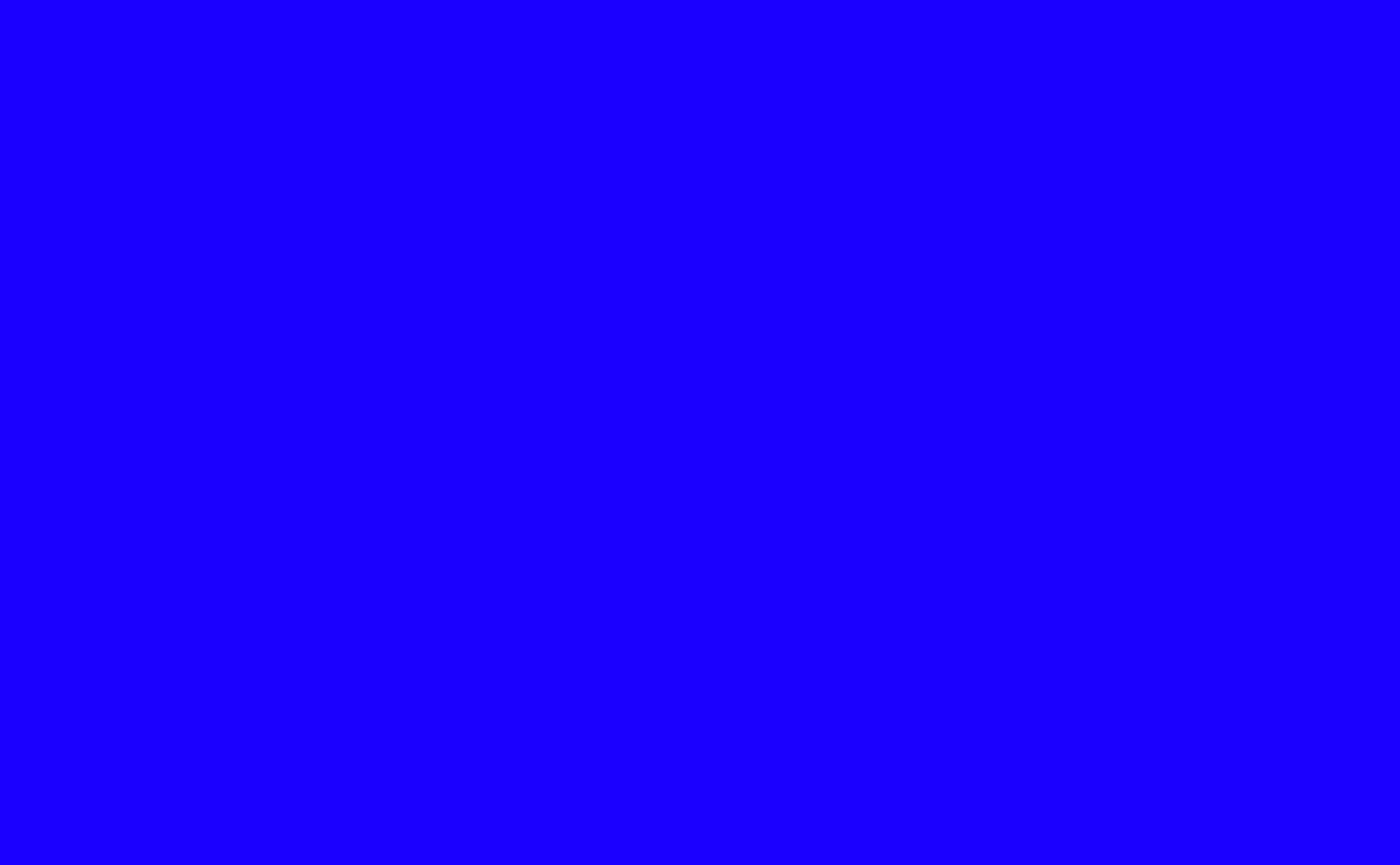

size_mag_=2.83e-01
[0.11 0.   1.  ]


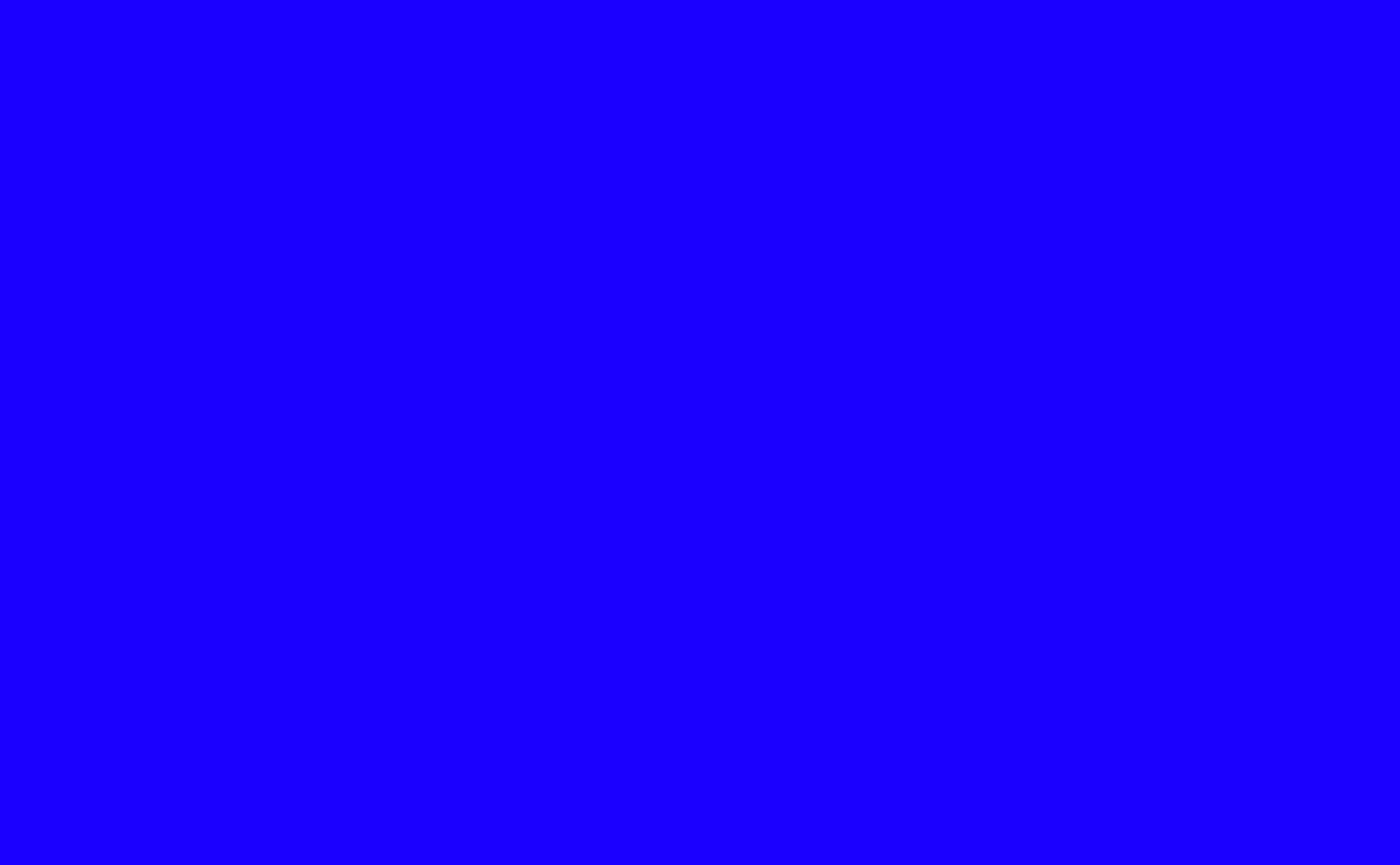

size_mag_=3.36e-01
[0.11 0.   1.  ]


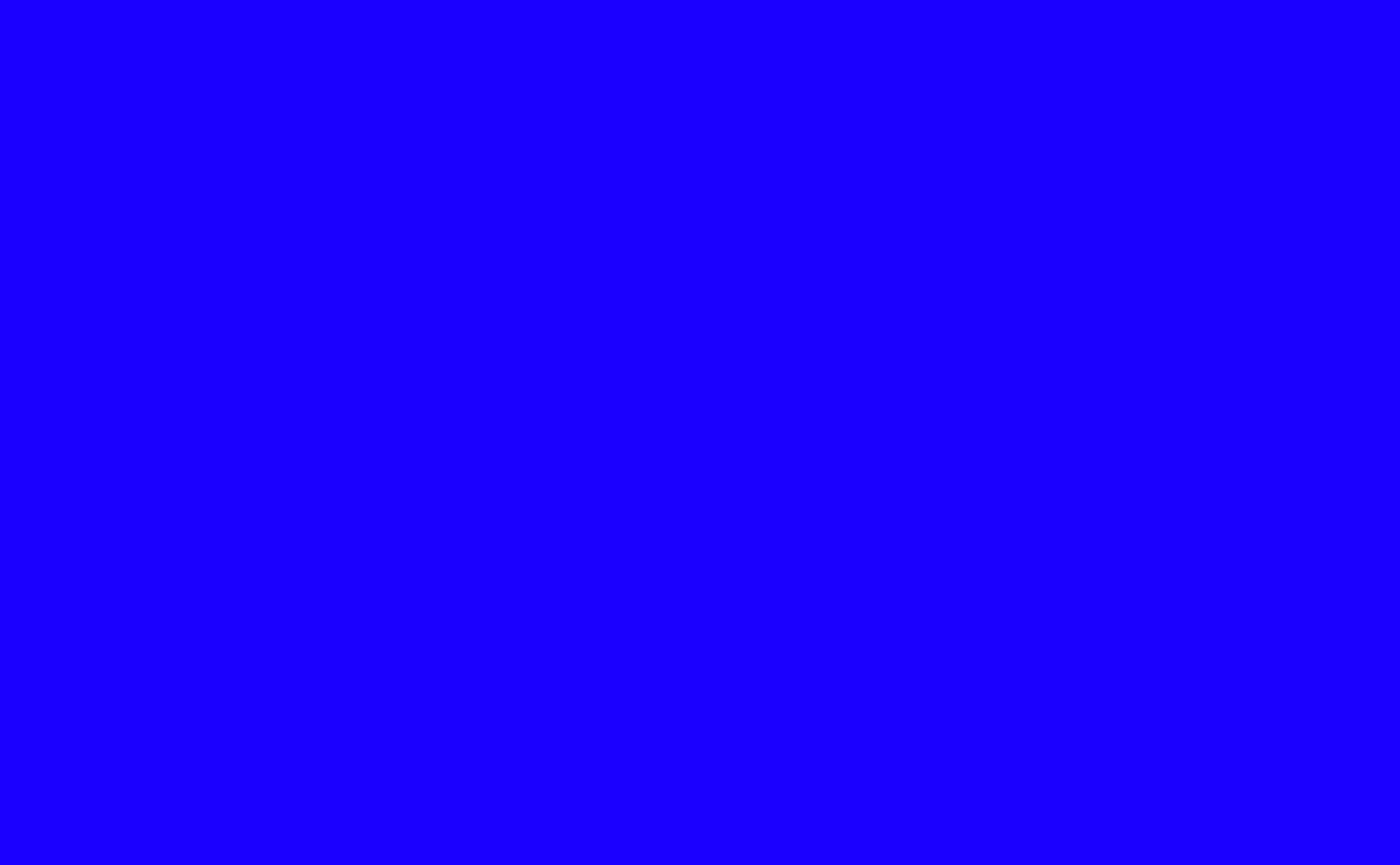

size_mag_=4.00e-01
[0.11 0.   1.  ]


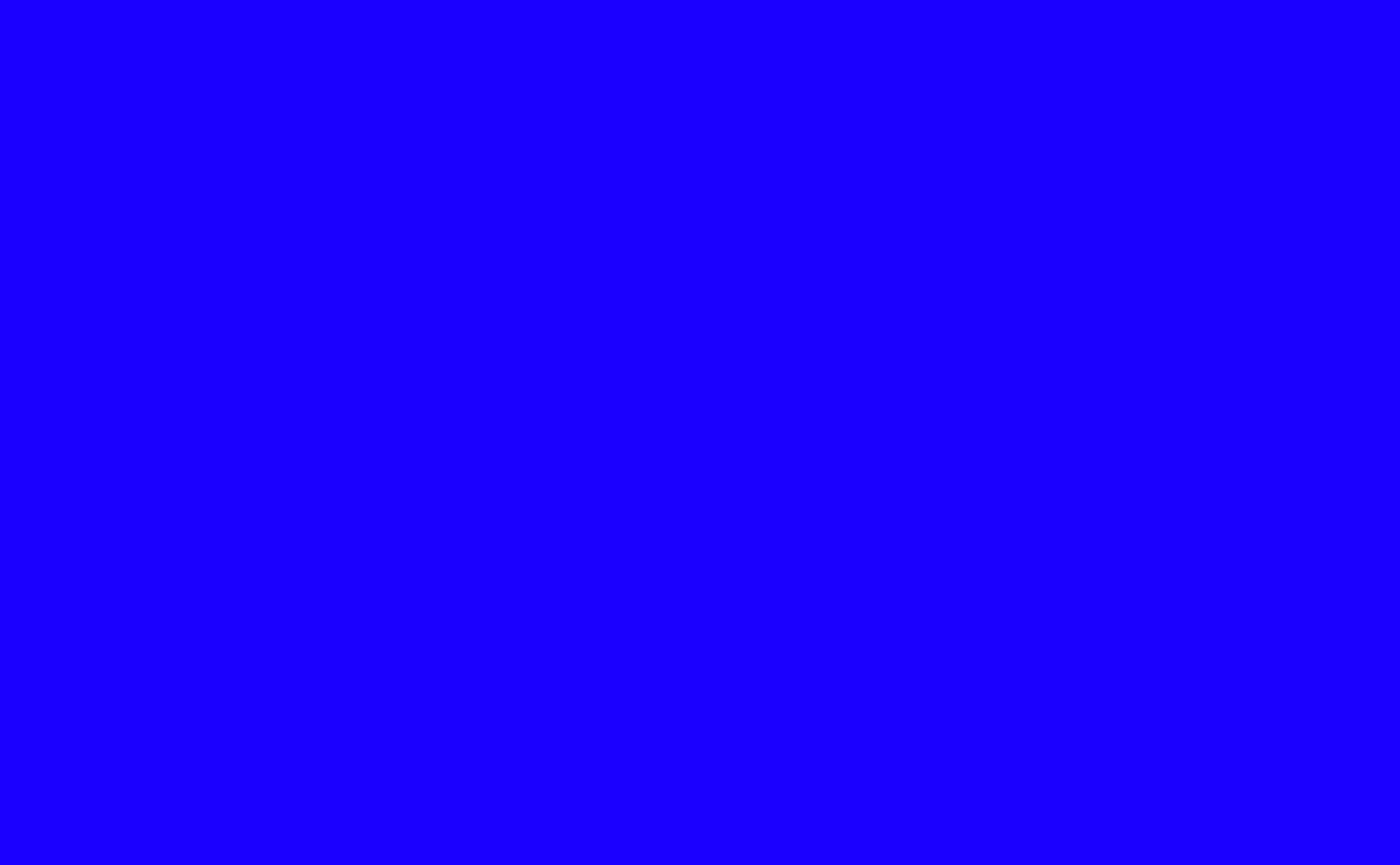

In [21]:
opts_ = opts.copy()
# for size_mag_ in np.geomspace(0.7, 1.4, N_scan, endpoint=True): 
for size_mag_ in np.geomspace(0.1, .40, N_scan, endpoint=True): 
    opts_.update(size_mag=size_mag_)
    print(f'{size_mag_=:.2e}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: size_mag (Dot Size)

First, this sweep changes dot size while preserving lattice topology and color controls. Second, the code scans size on a geometric scale and displays each resulting image, which is necessary because perceived size effects are nonlinear. Third, very small dots can approach threshold globally, very large dots become robustly visible across the field, and intermediate sizes often produce the strongest center-periphery dissociation because foveal sampling resolves fine contours that peripheral integration smooths out.

## c_mean

c_mean_=400.00
[0.11 0.   1.  ]


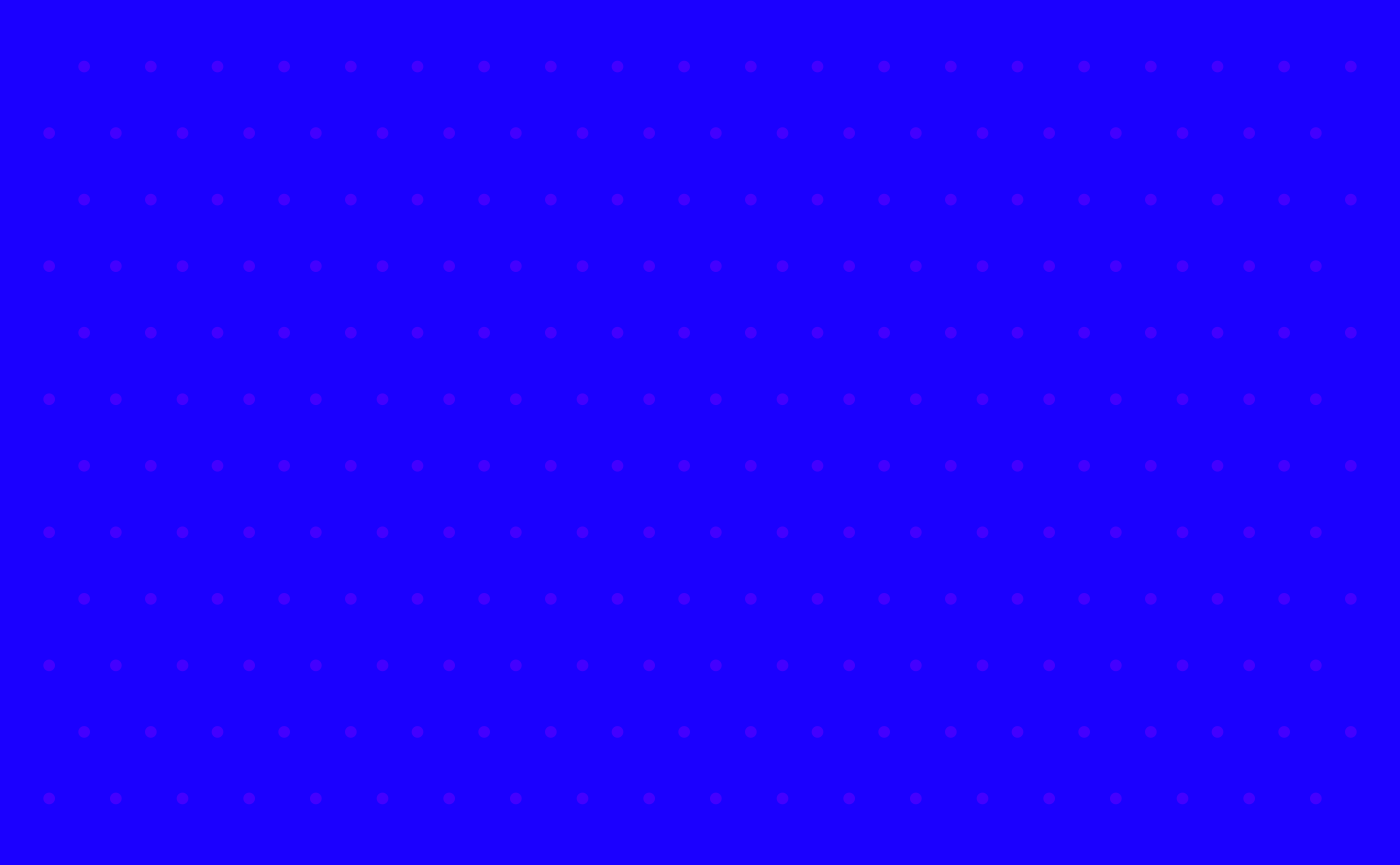

c_mean_=438.89
[0.11 0.   1.  ]


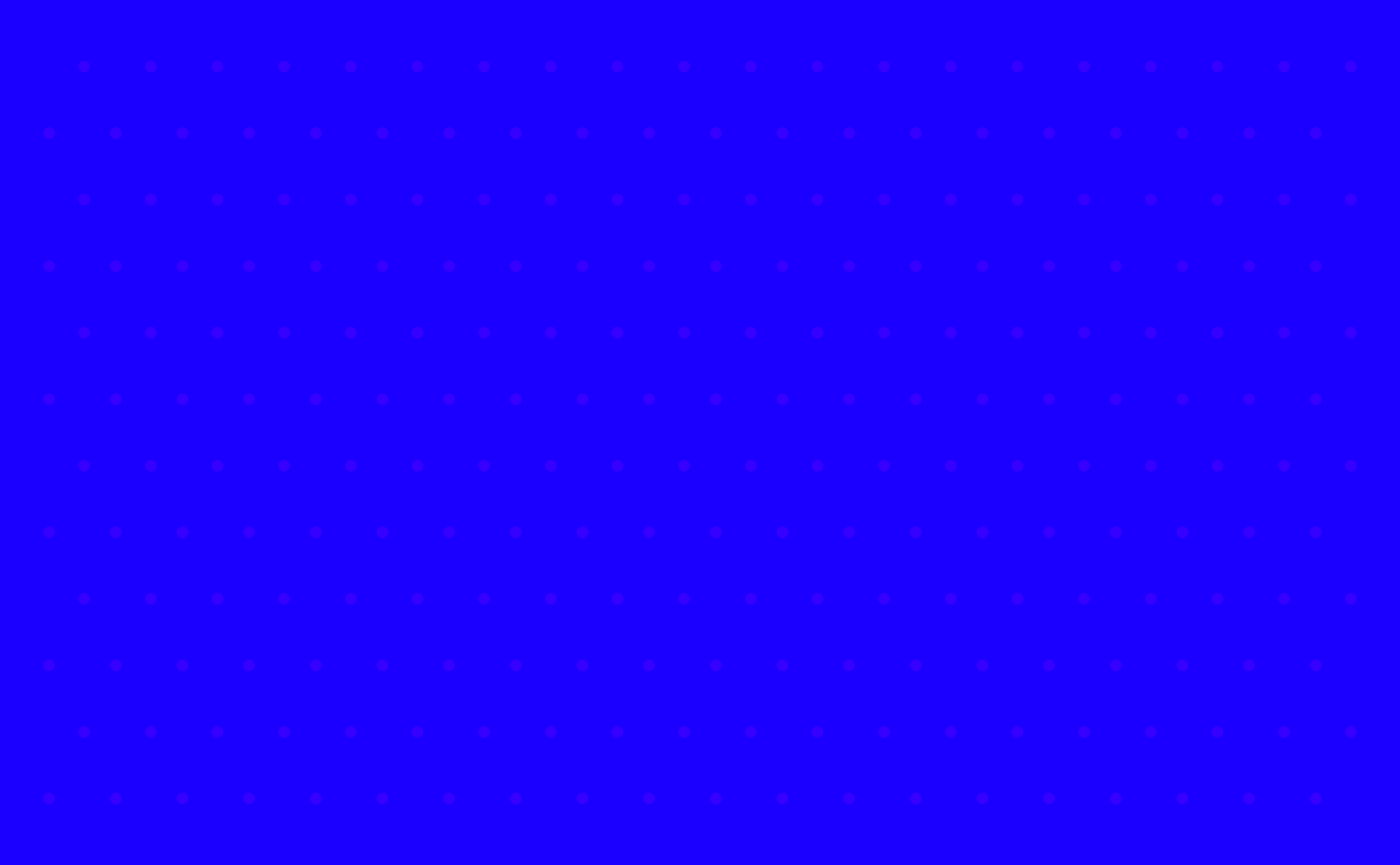

c_mean_=477.78
[0.11 0.   1.  ]


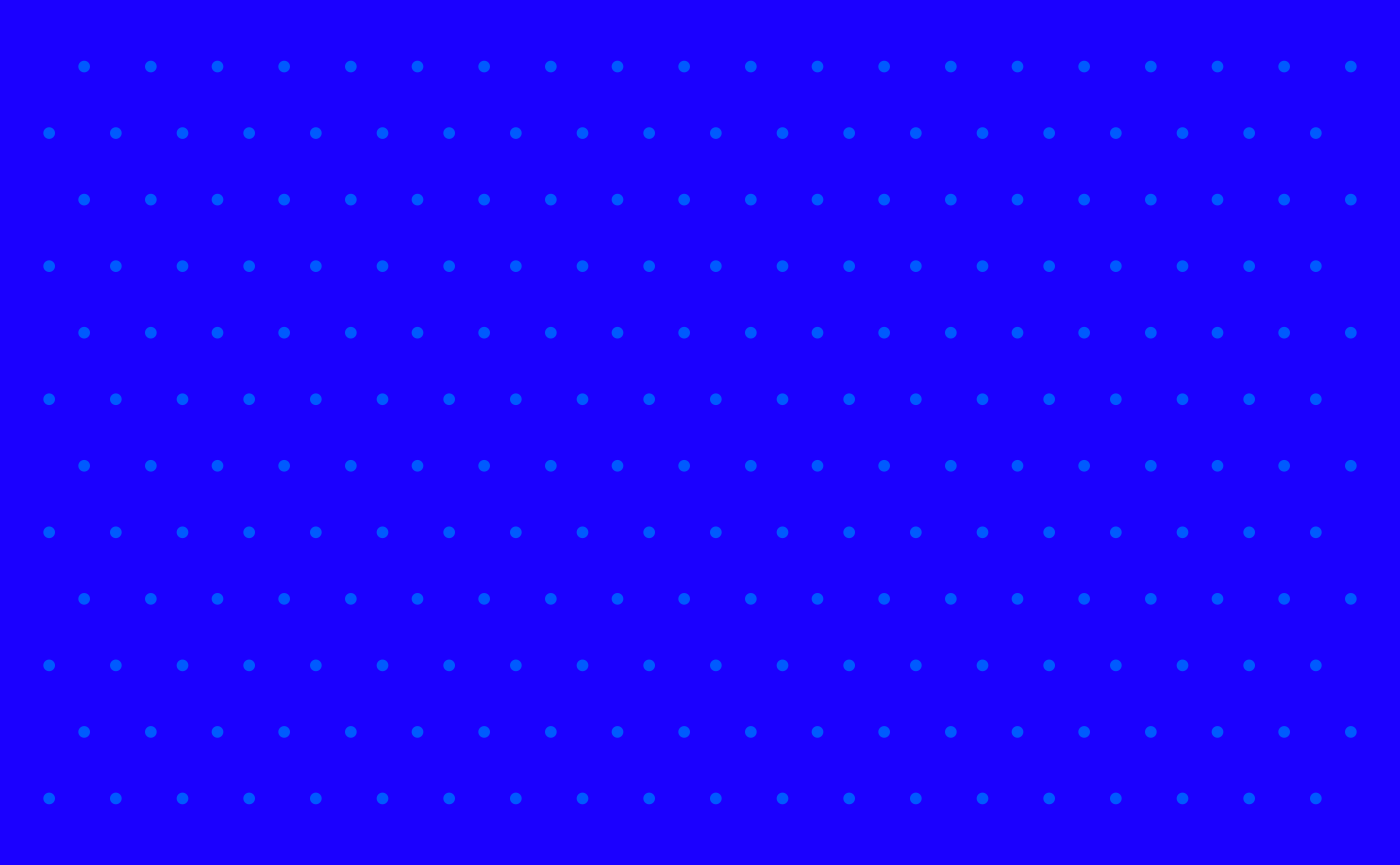

c_mean_=516.67
[0.11 0.   1.  ]


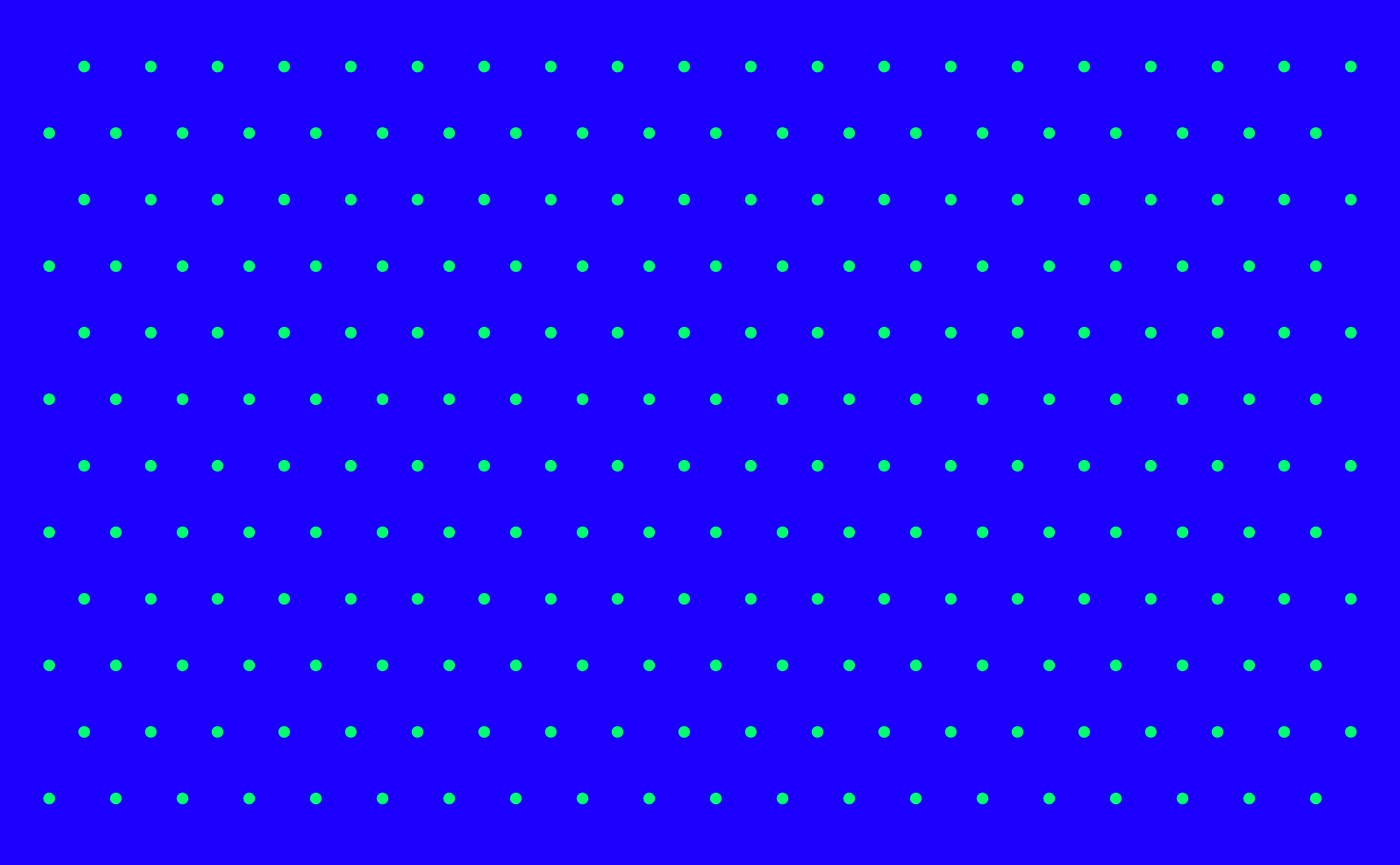

c_mean_=555.56
[0.11 0.   1.  ]


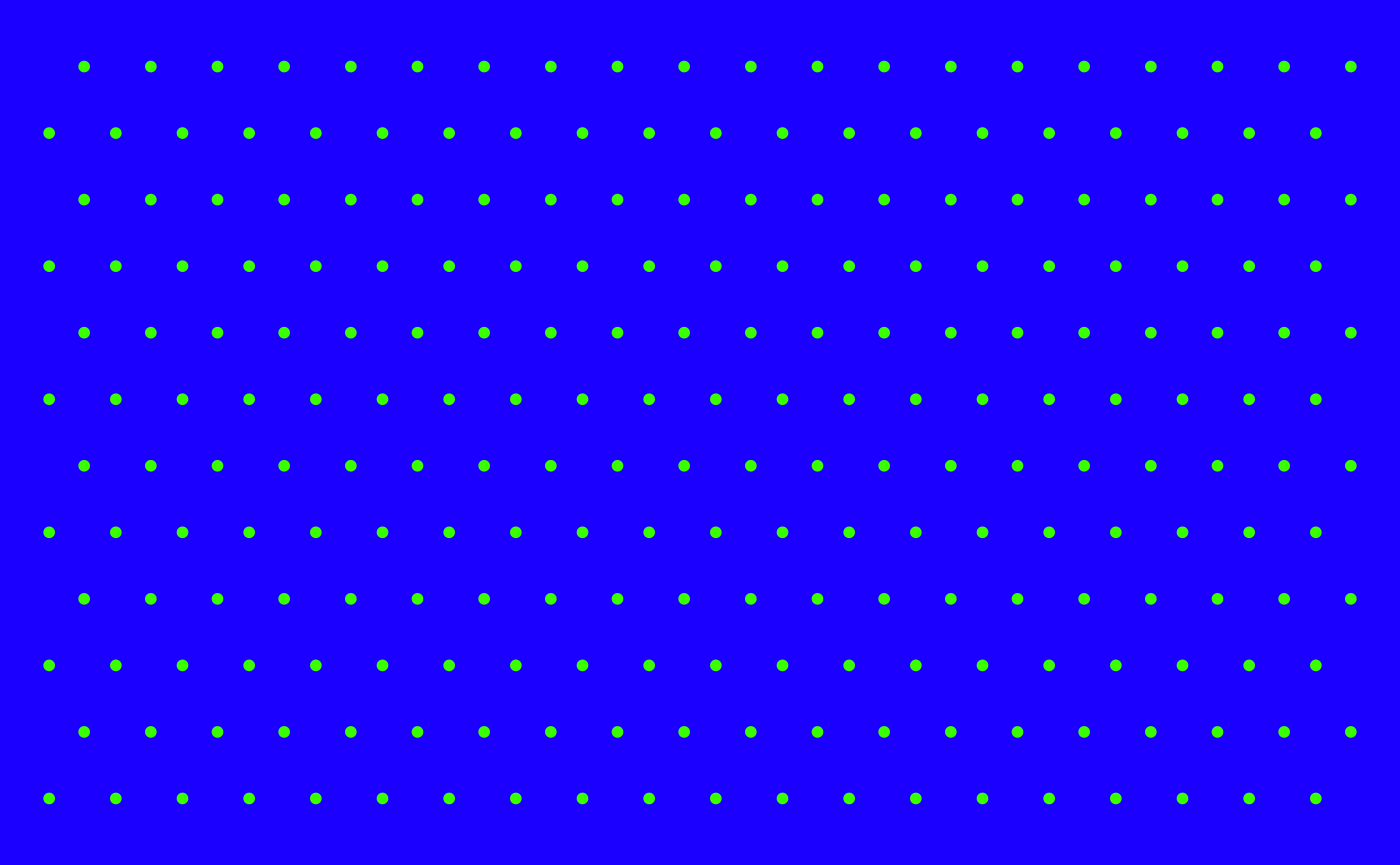

c_mean_=594.44
[0.11 0.   1.  ]


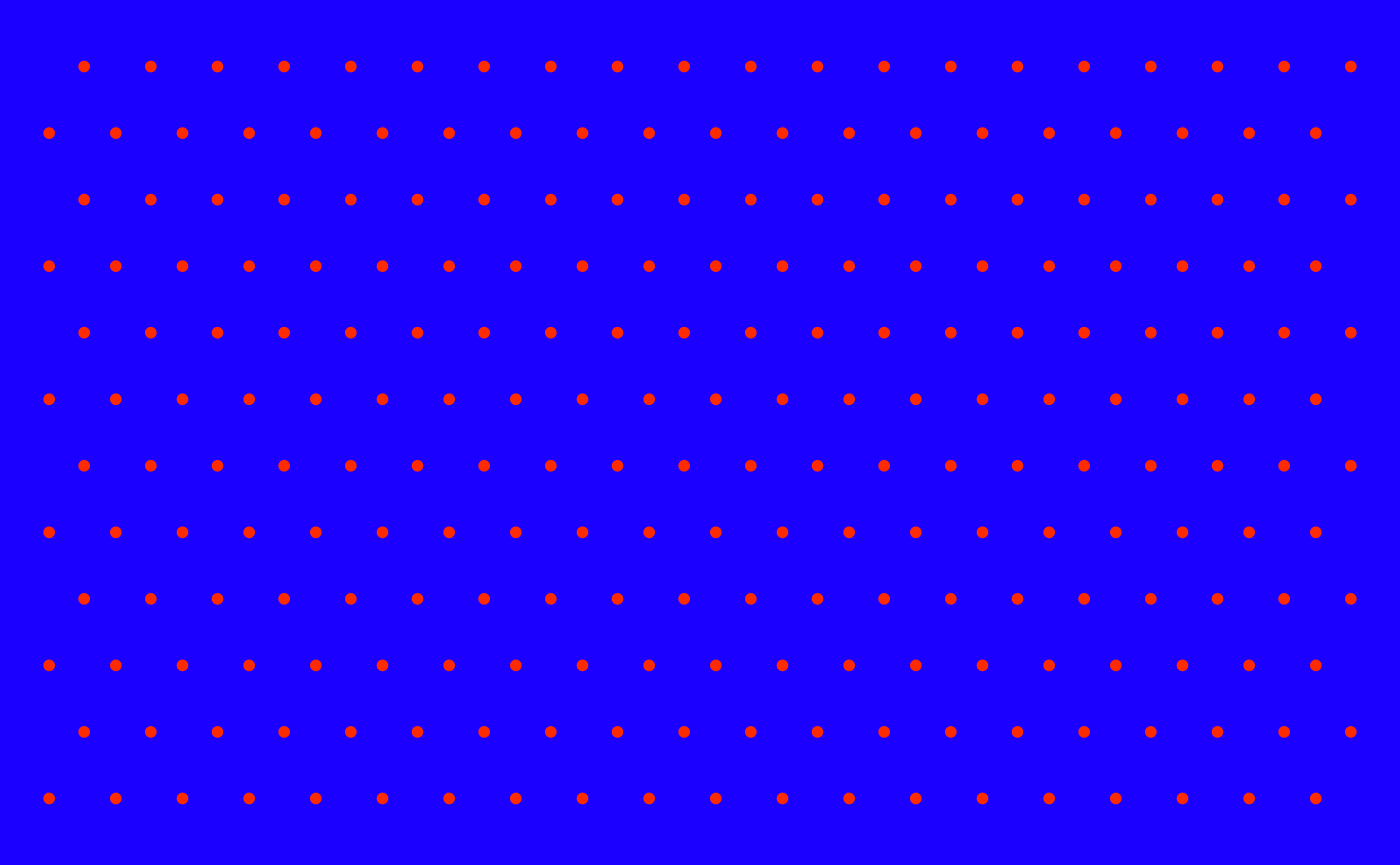

c_mean_=633.33
[0.11 0.   1.  ]


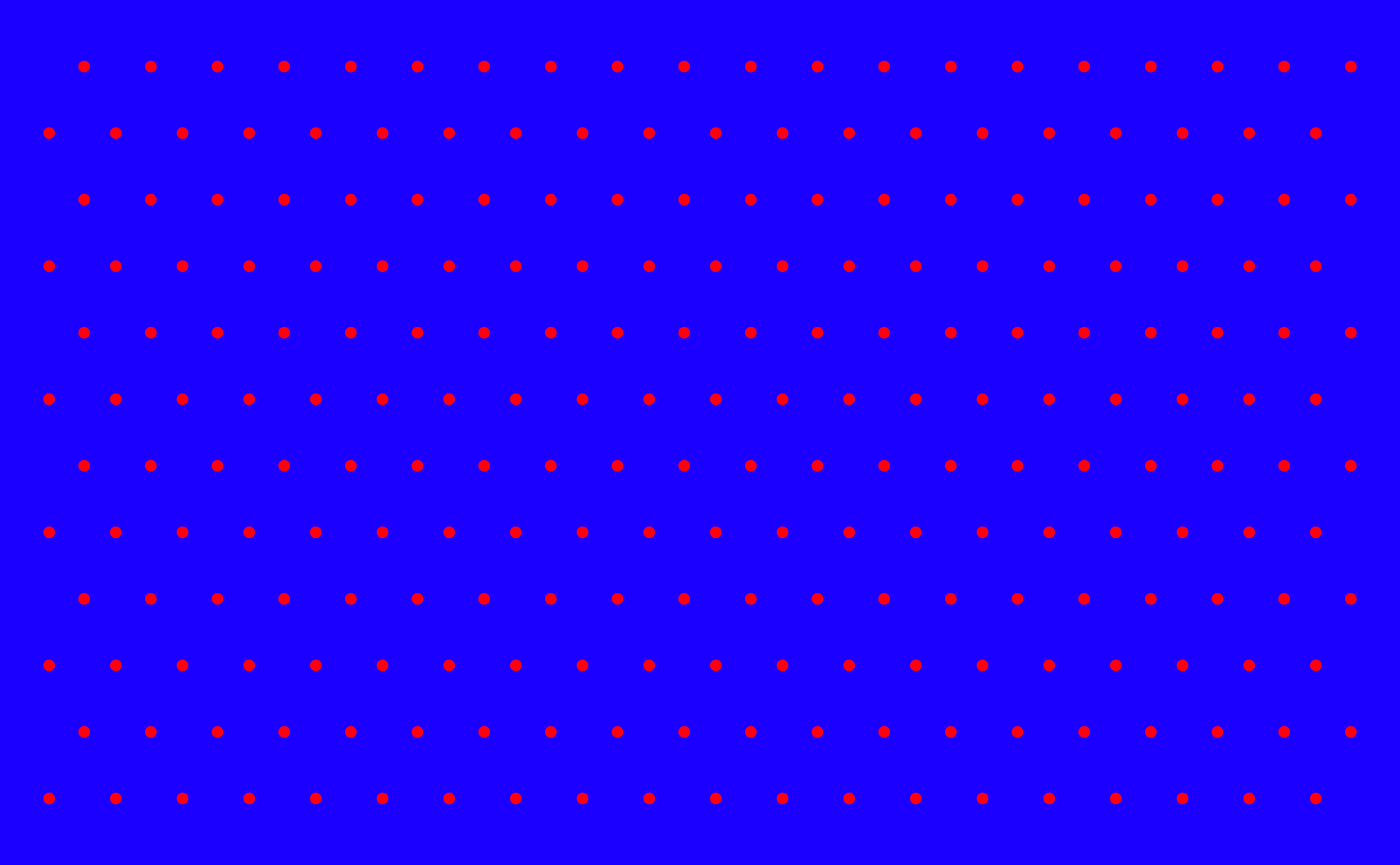

c_mean_=672.22
[0.11 0.   1.  ]


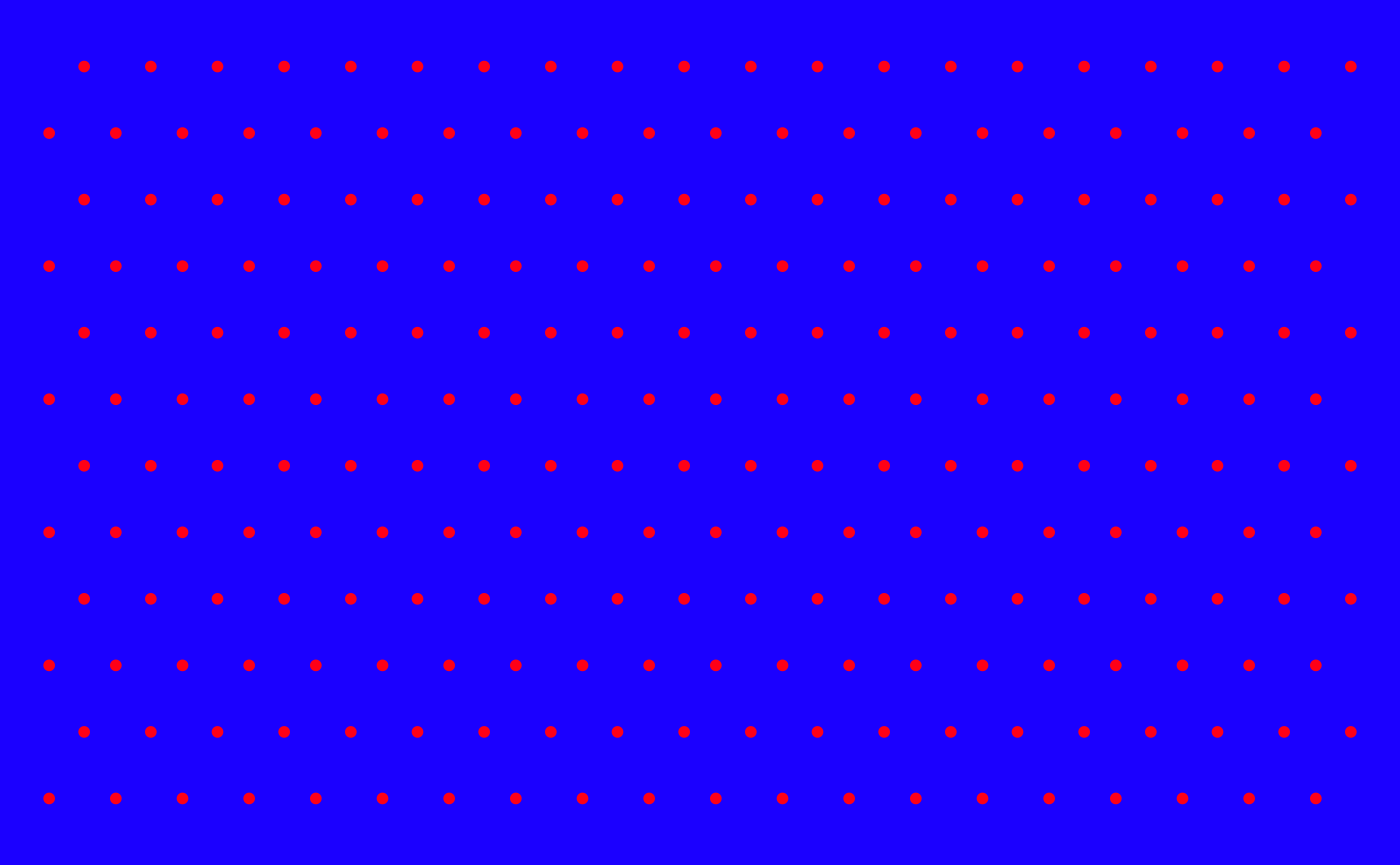

c_mean_=711.11
[0.11 0.   1.  ]


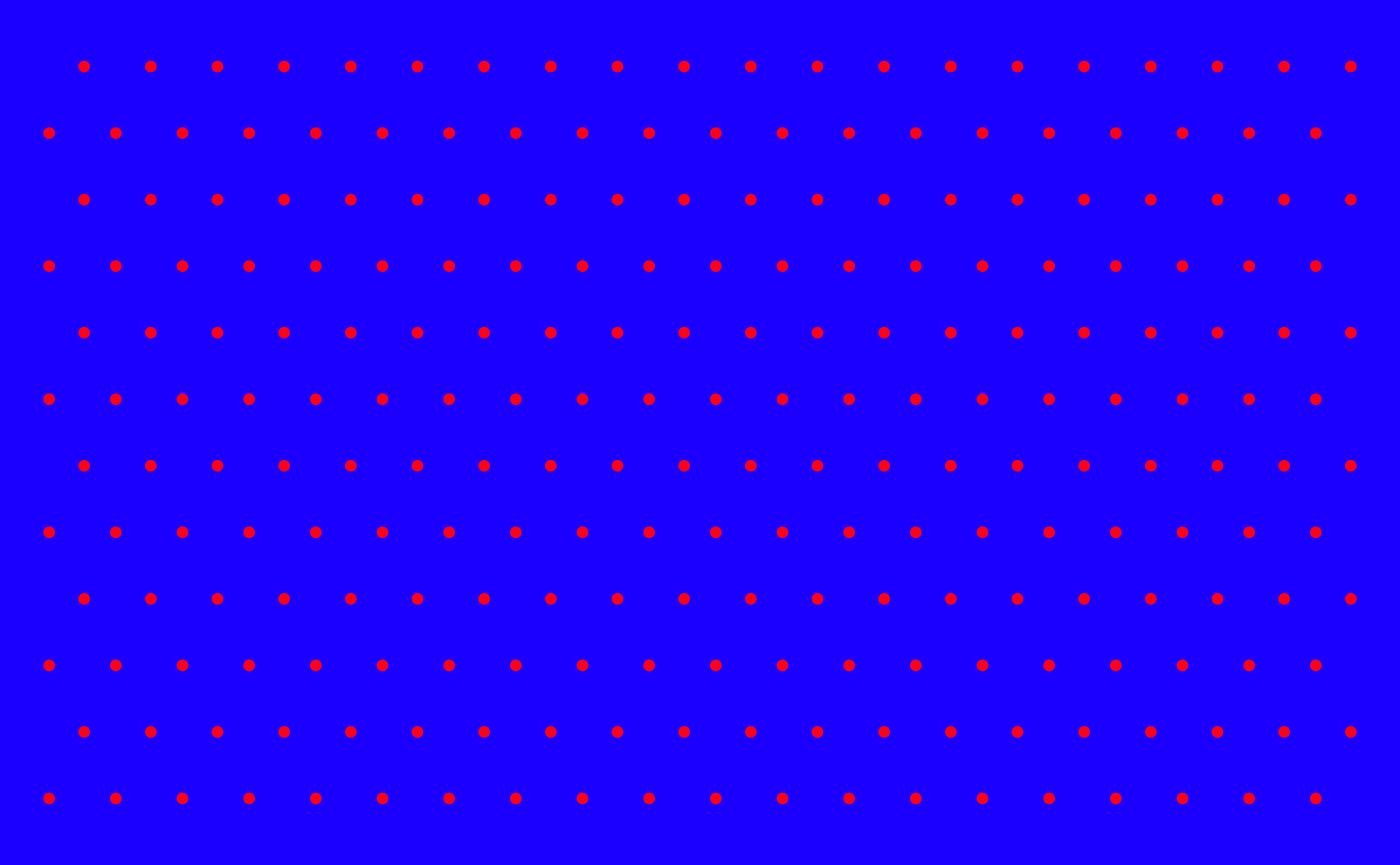

In [22]:
opts_ = opts.copy()
for c_mean_ in np.linspace(400., 750., N_scan, endpoint=False): 
    opts_.update(c_mean=c_mean_)
    print(f'{c_mean_=:.2f}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: c_mean (Mean Hue)

First, this sweep changes the mean hue while keeping geometric structure fixed. Second, the code rotates hue around the full color circle and displays each frame so that chromatic alignment with the background can be assessed directly. Third, some hue sectors increase perceived separation and others reduce it, and this modulation is expected because cone-opponent pathways dominate central chromatic discrimination whereas peripheral vision shows weaker color-resolved segmentation.

## c_std


c_std_=0.00e+00
[nan nan nan]


/var/folders/3s/q2x8bxzj43g4rdvb2wjt67640000gq/T/ipykernel_77215/3227298543.py:9: RuntimeWarning: divide by zero encountered in divide
  spec = np.exp(-0.5 * ((wavelengths - c_mean) / c_std) ** 2)
/var/folders/3s/q2x8bxzj43g4rdvb2wjt67640000gq/T/ipykernel_77215/3227298543.py:9: RuntimeWarning: invalid value encountered in divide
  spec = np.exp(-0.5 * ((wavelengths - c_mean) / c_std) ** 2)


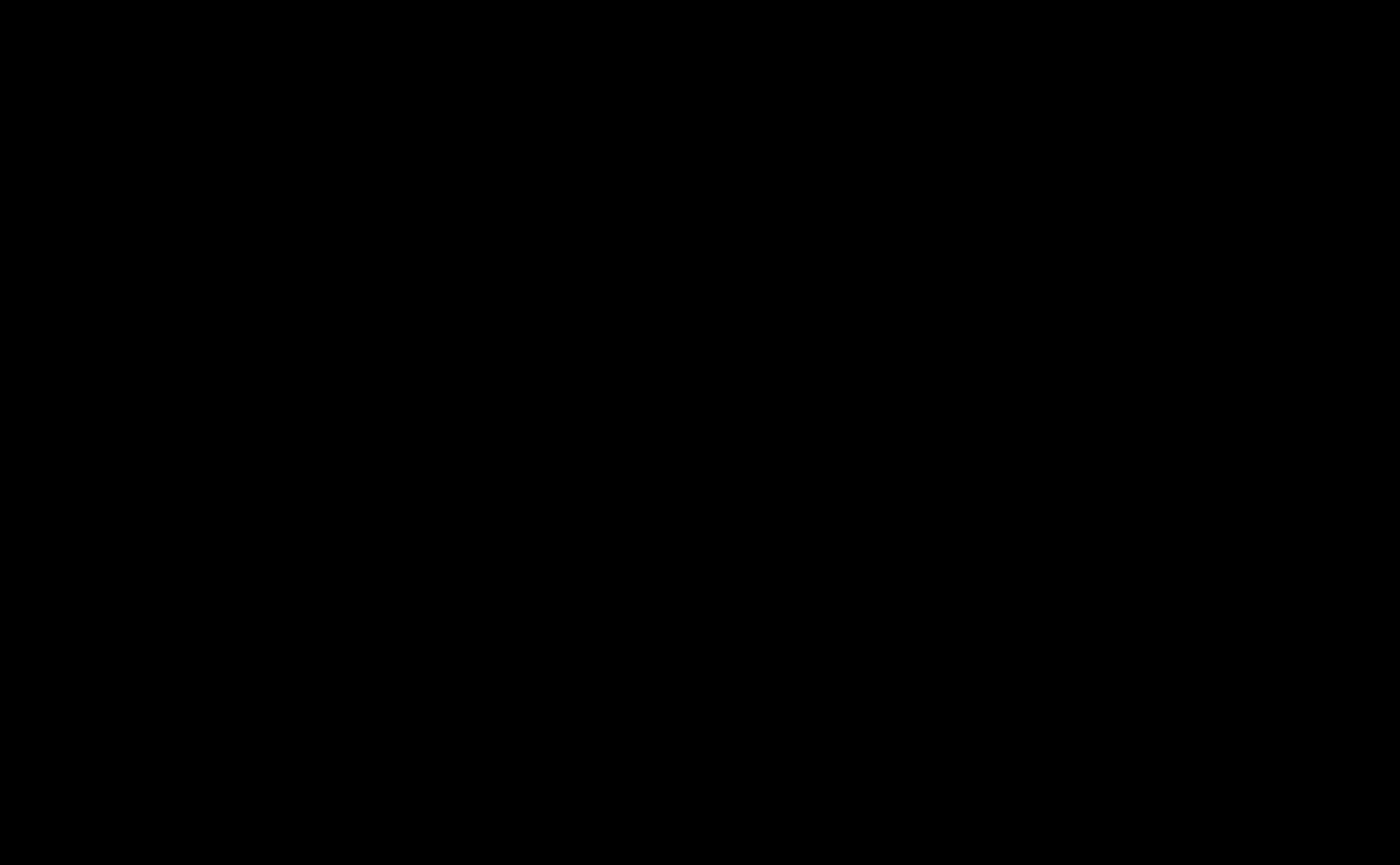

c_std_=3.33e+00
[0.12 0.   1.  ]


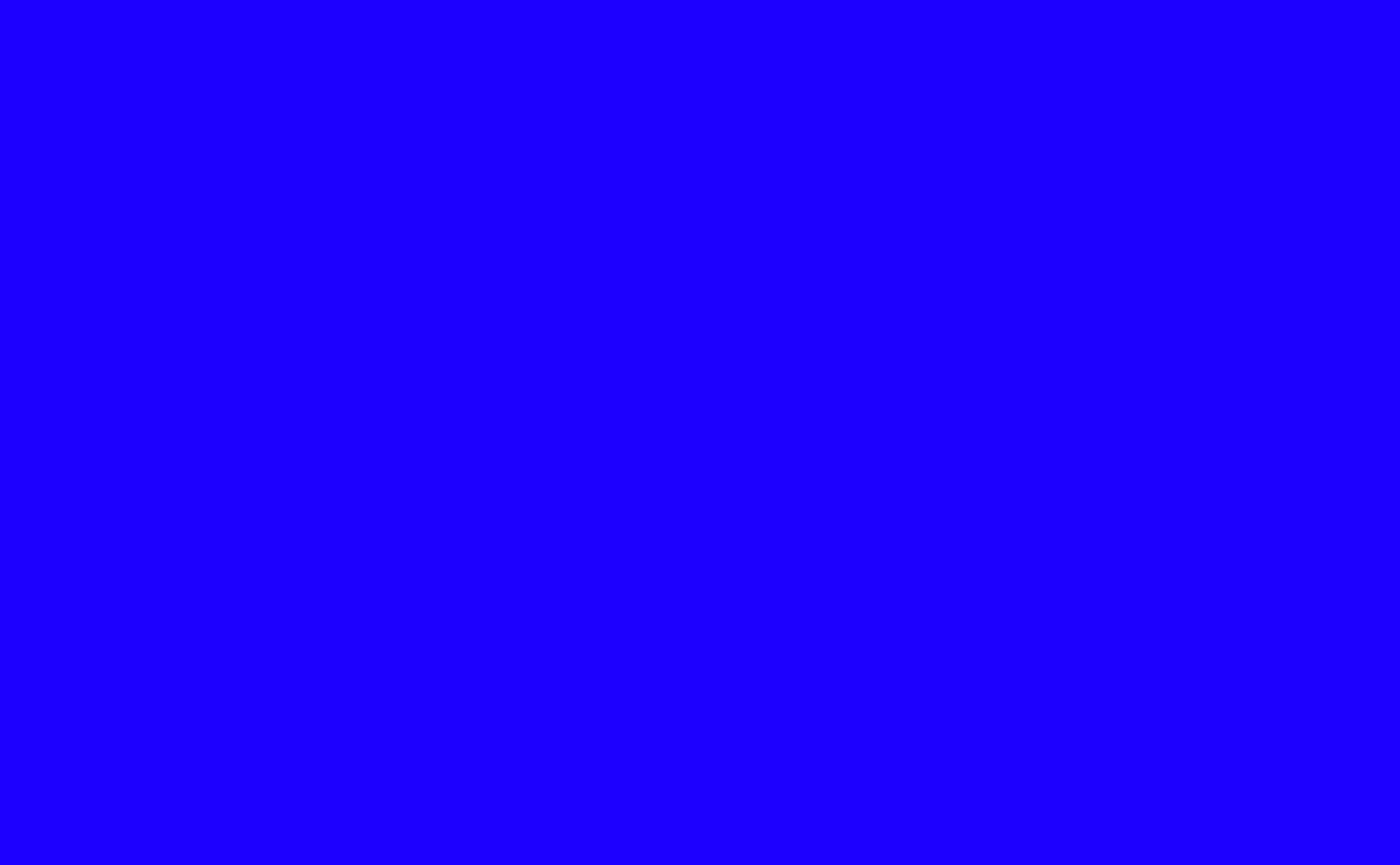

c_std_=6.67e+00
[0.11 0.   1.  ]


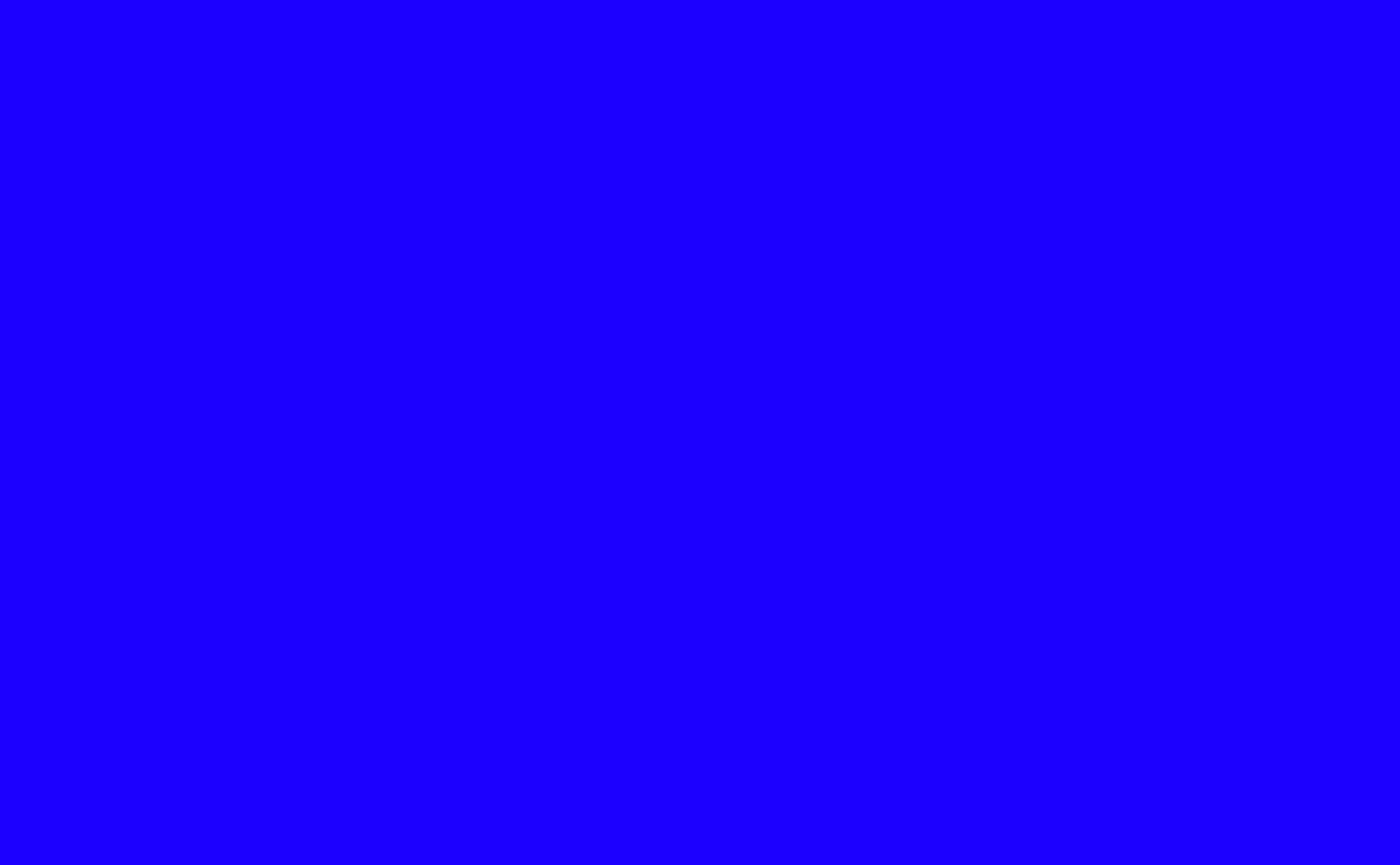

c_std_=1.00e+01
[0.1 0.  1. ]


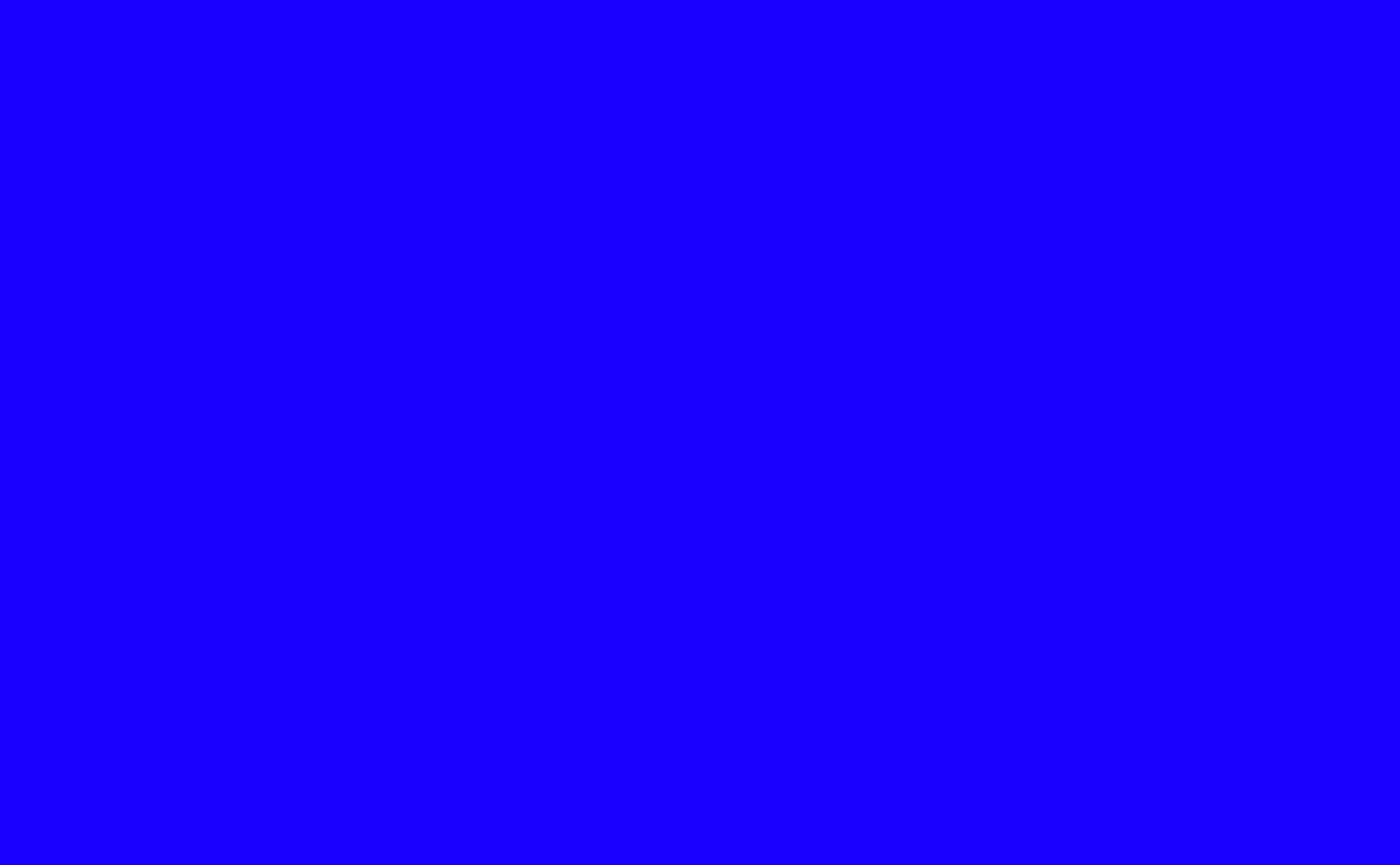

c_std_=1.33e+01
[0.09 0.   1.  ]


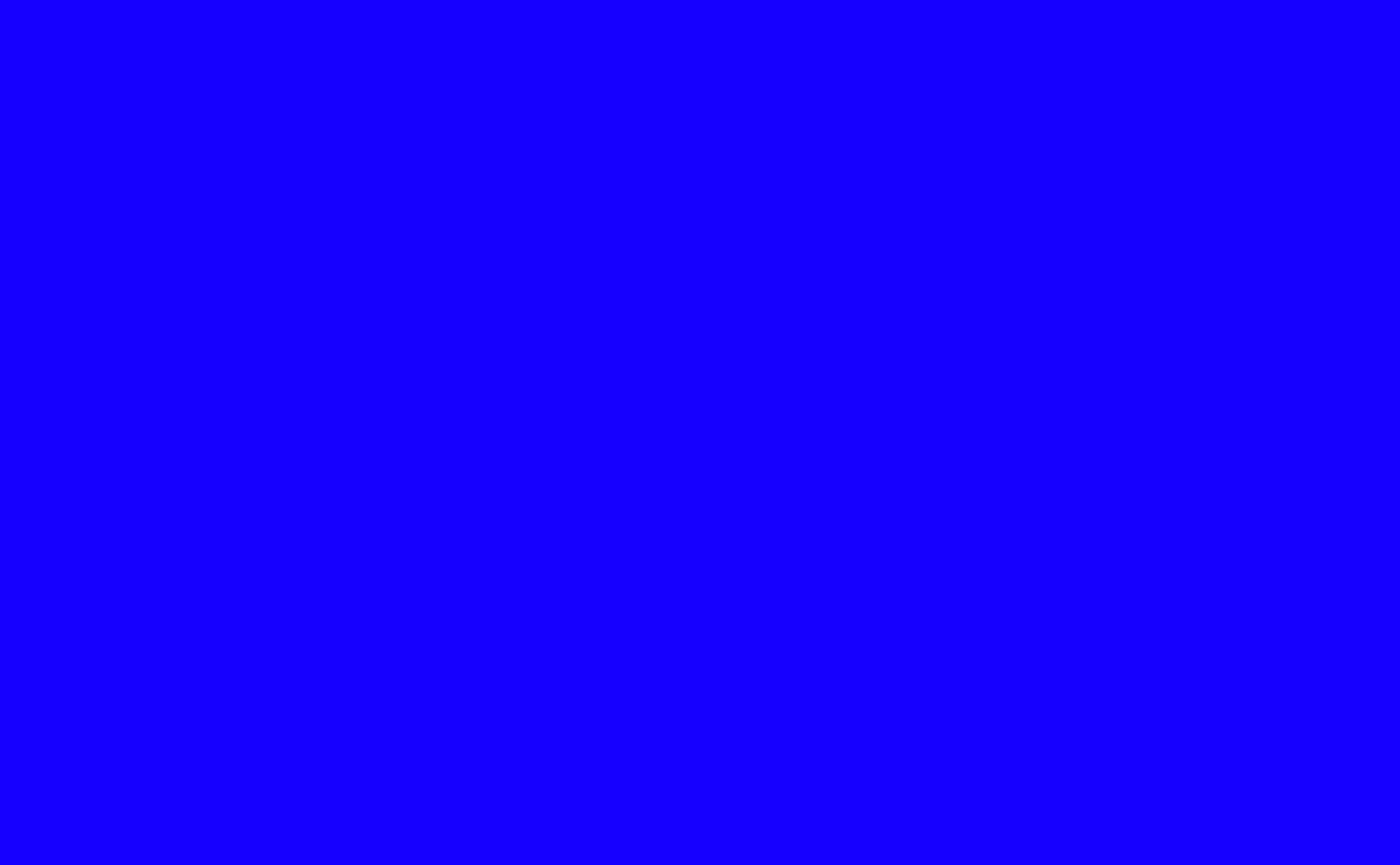

c_std_=1.67e+01
[0.07 0.   1.  ]


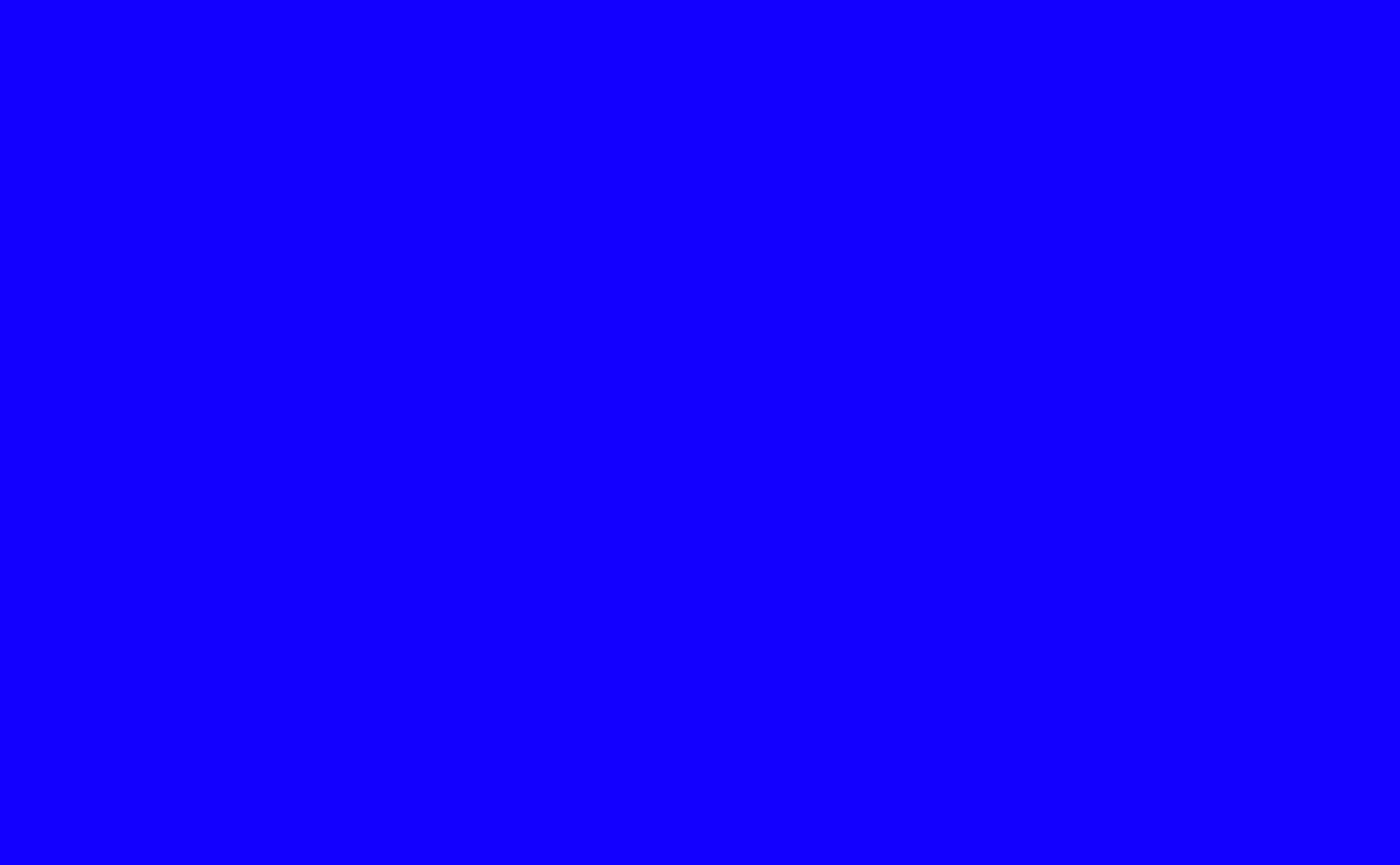

c_std_=2.00e+01
[0.04 0.   1.  ]


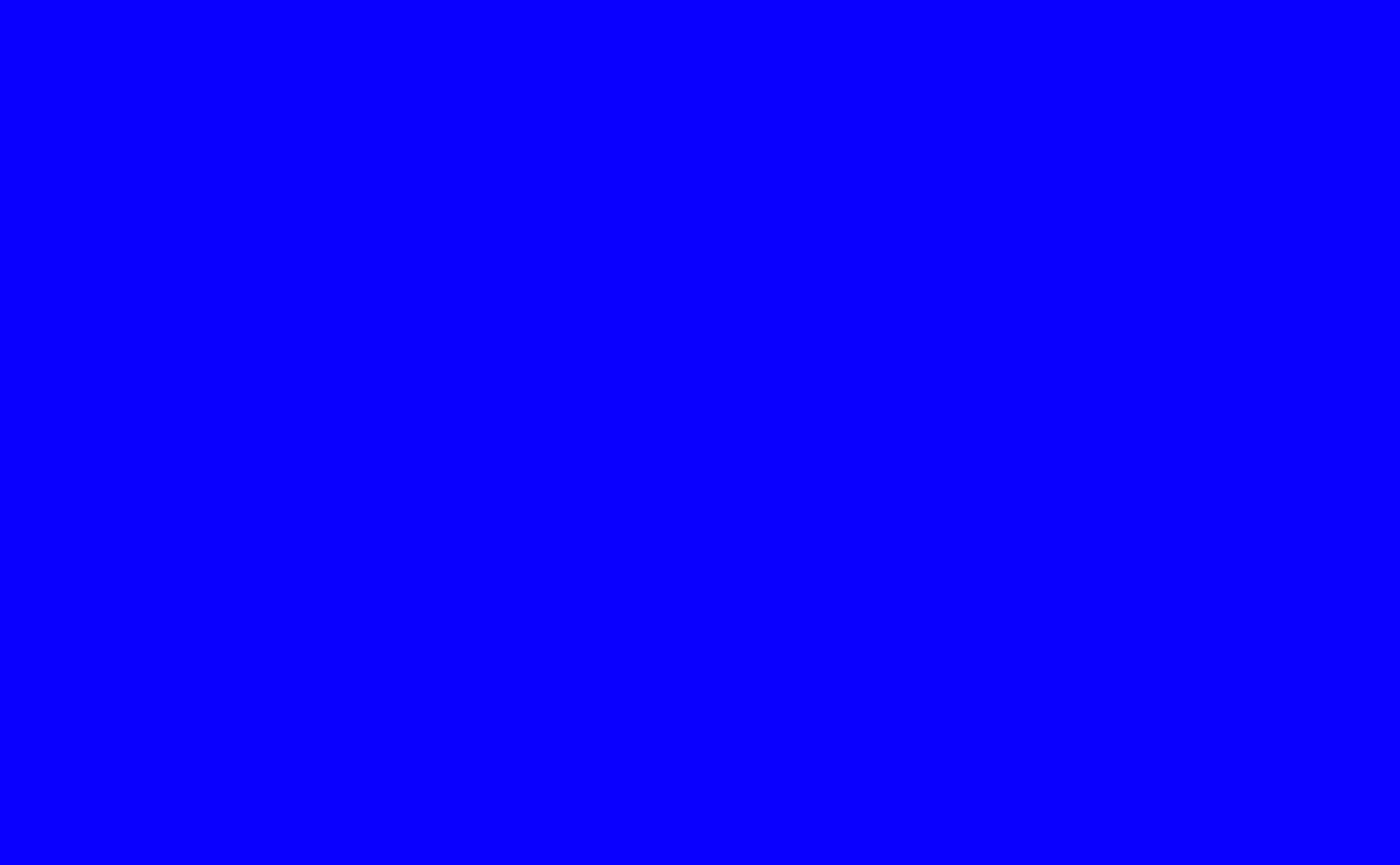

c_std_=2.33e+01
[0. 0. 1.]


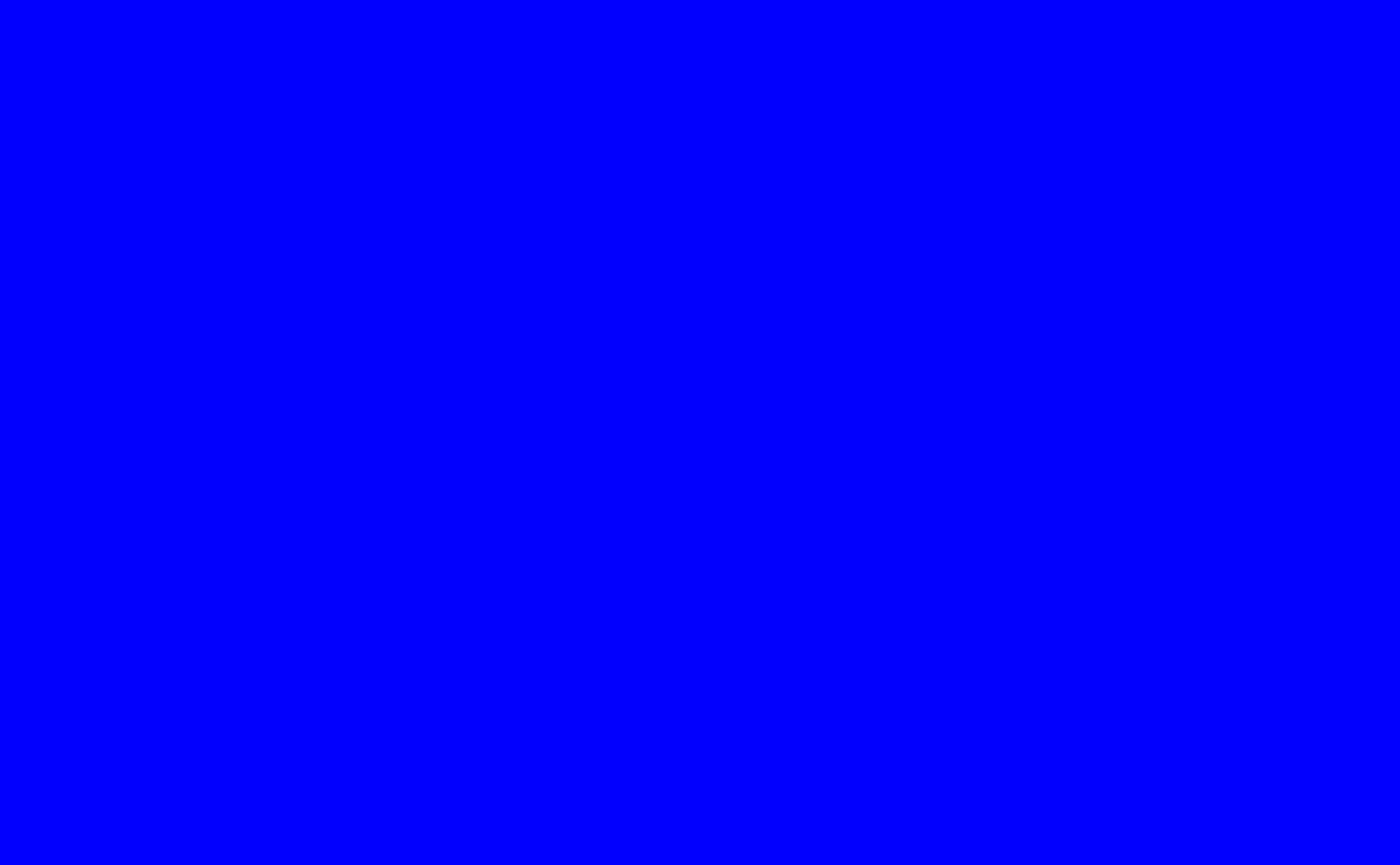

c_std_=2.67e+01
[0.   0.04 1.  ]


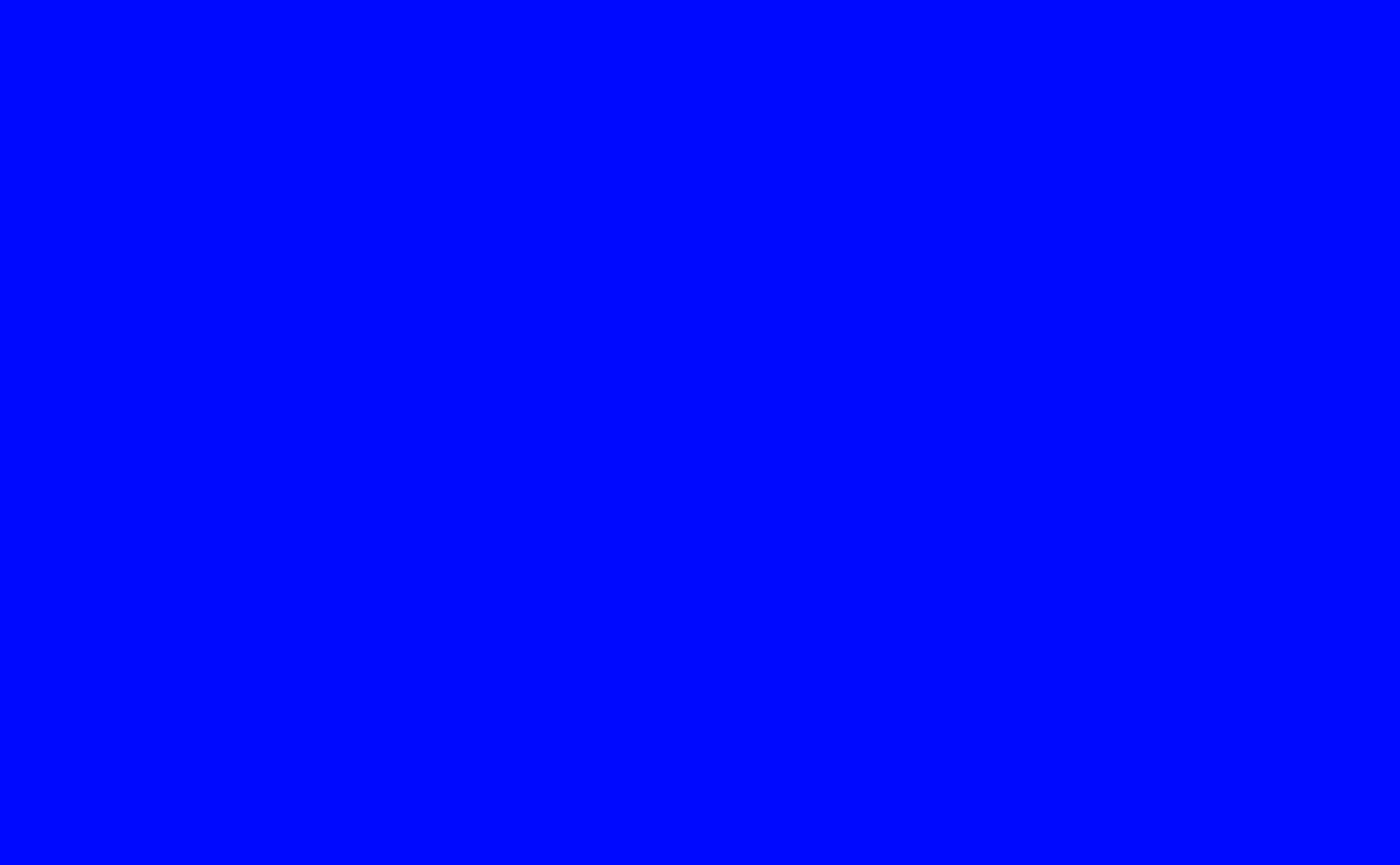

In [23]:
opts_ = opts.copy()
for c_std_ in np.linspace(0., 30, N_scan, endpoint=False): 
    opts_.update(c_std=c_std_)
    print(f'{c_std_=:.2e}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: c_std (Hue Spread)

First, this sweep changes hue variability across dots, which controls chromatic heterogeneity without changing lattice geometry. Second, the code progressively increases hue spread and displays each output to reveal how local irregularity affects grouping. Third, low spread tends to flatten differences, high spread can raise salience everywhere, and moderate spread often best preserves a central parsing advantage over peripheral fusion.

## N_H

N_=np.int64(10)
[0.11 0.   1.  ]


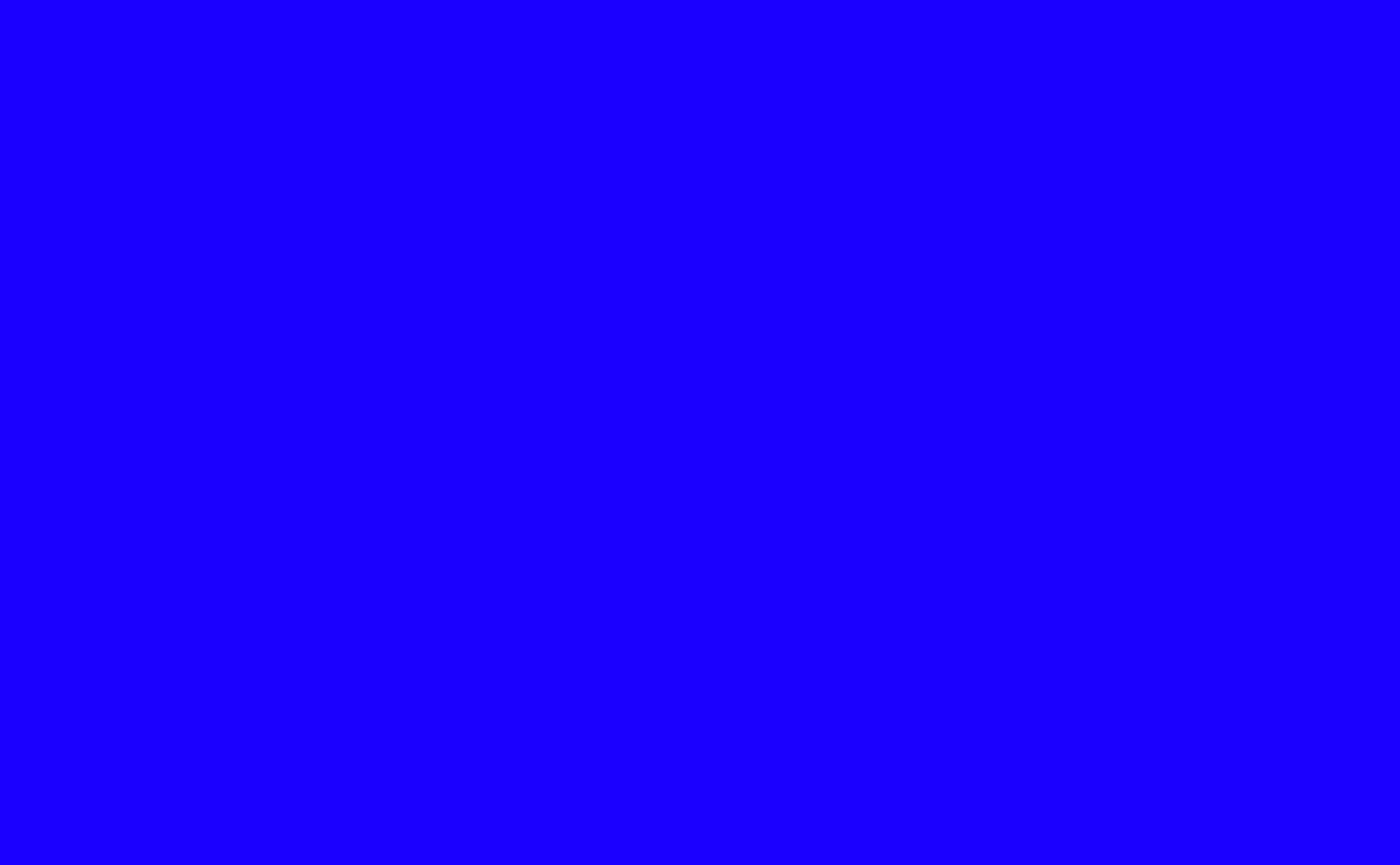

N_=np.int64(11)
[0.11 0.   1.  ]


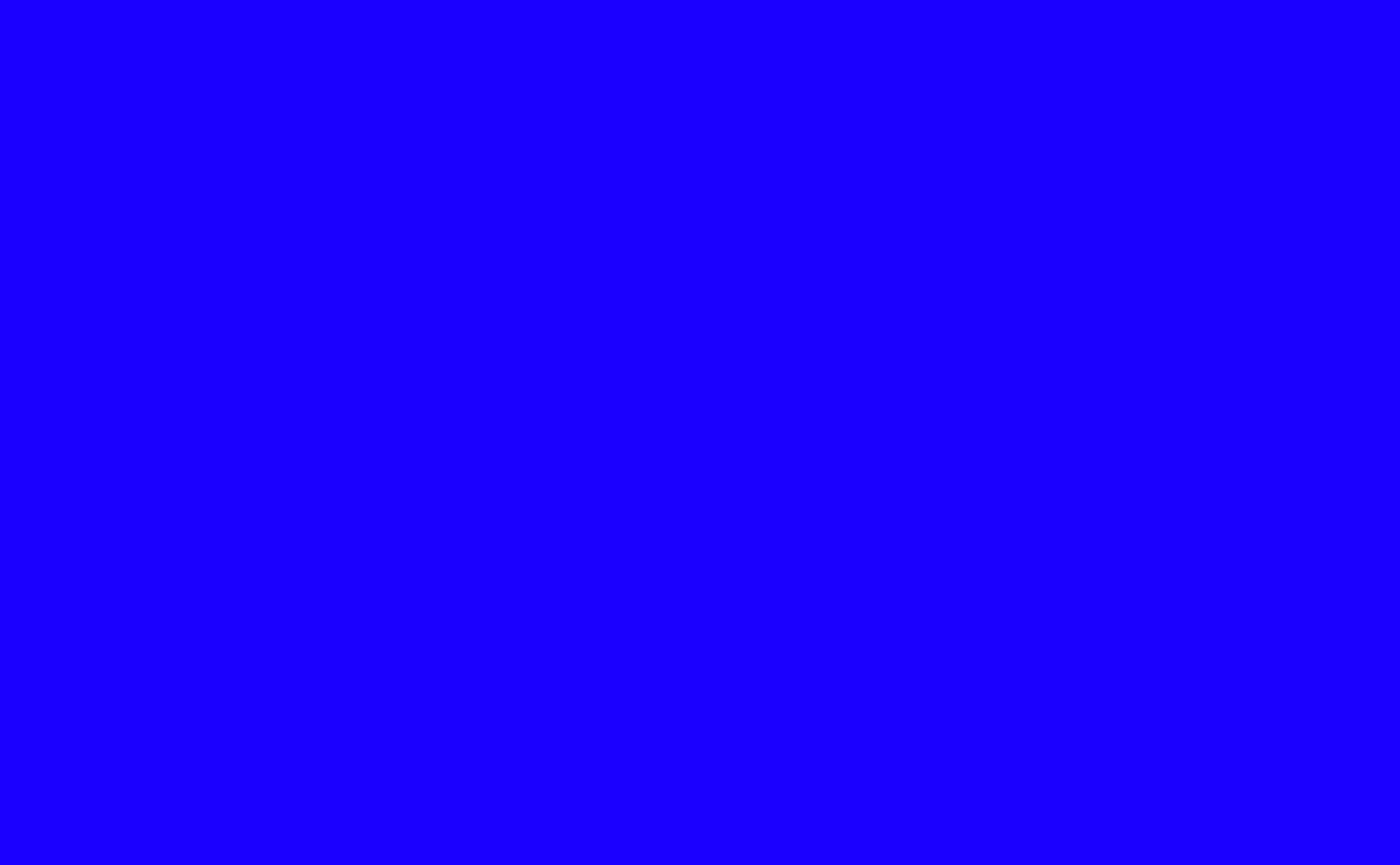

N_=np.int64(14)
[0.11 0.   1.  ]


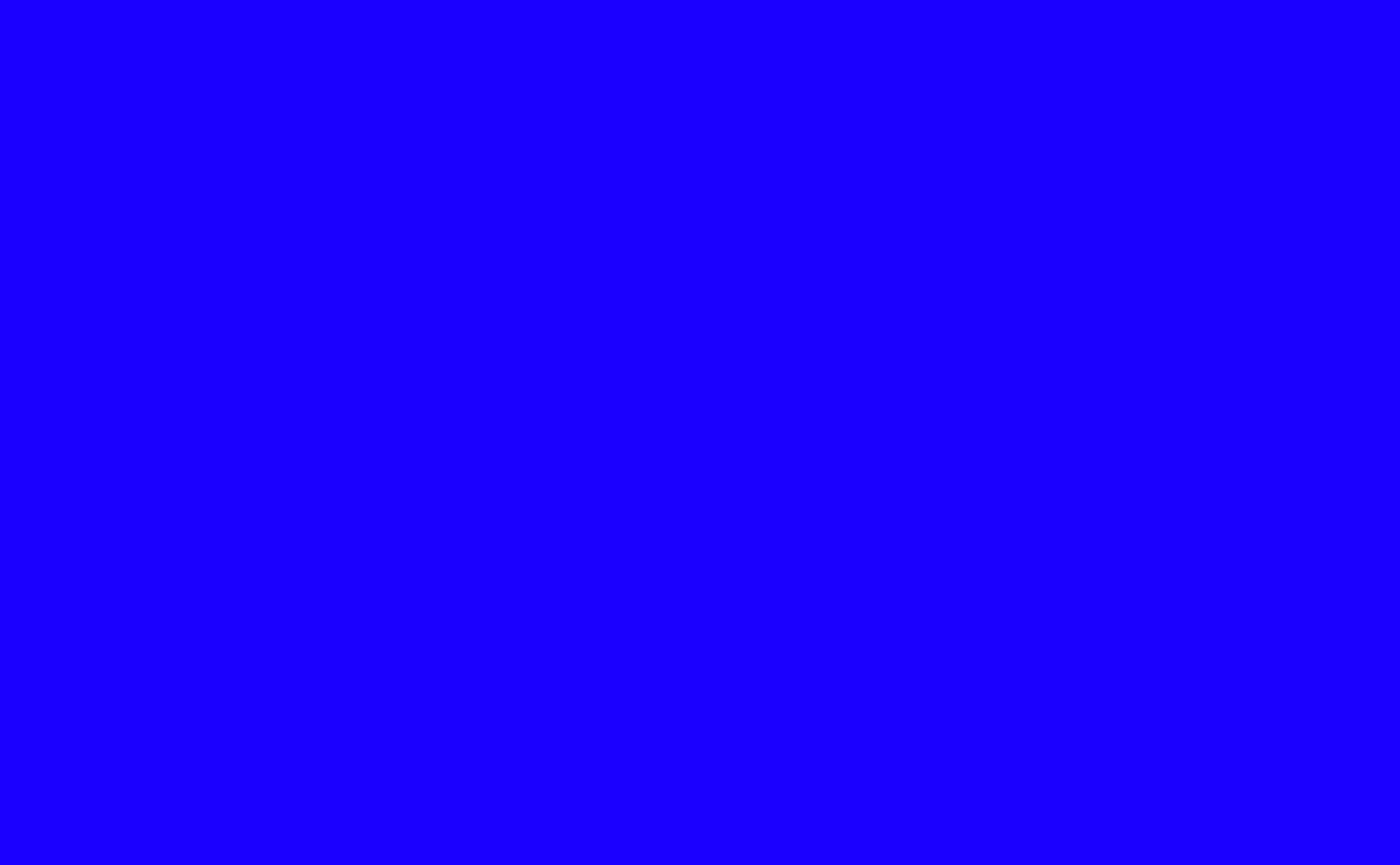

N_=np.int64(16)
[0.11 0.   1.  ]


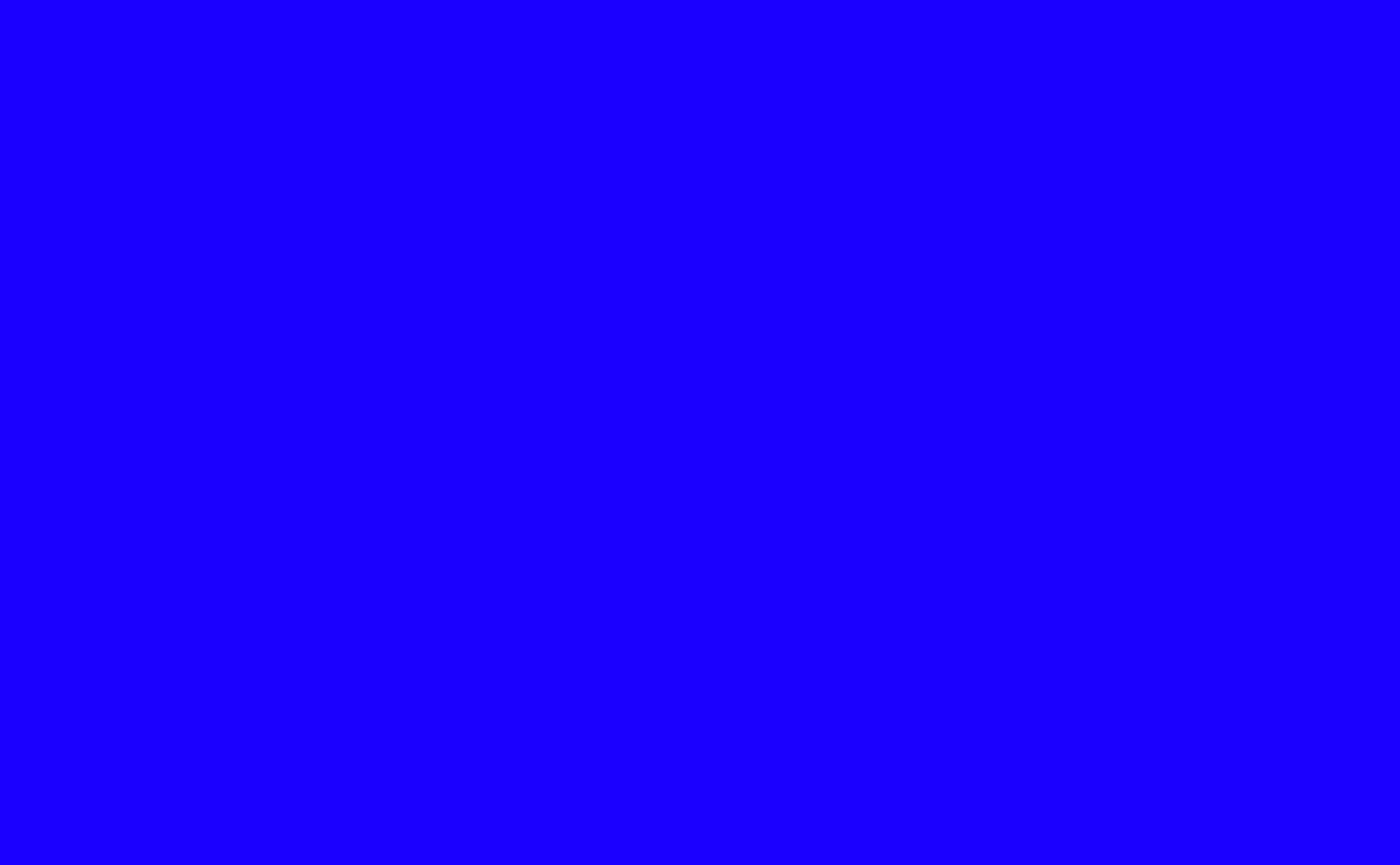

N_=np.int64(20)
[0.11 0.   1.  ]


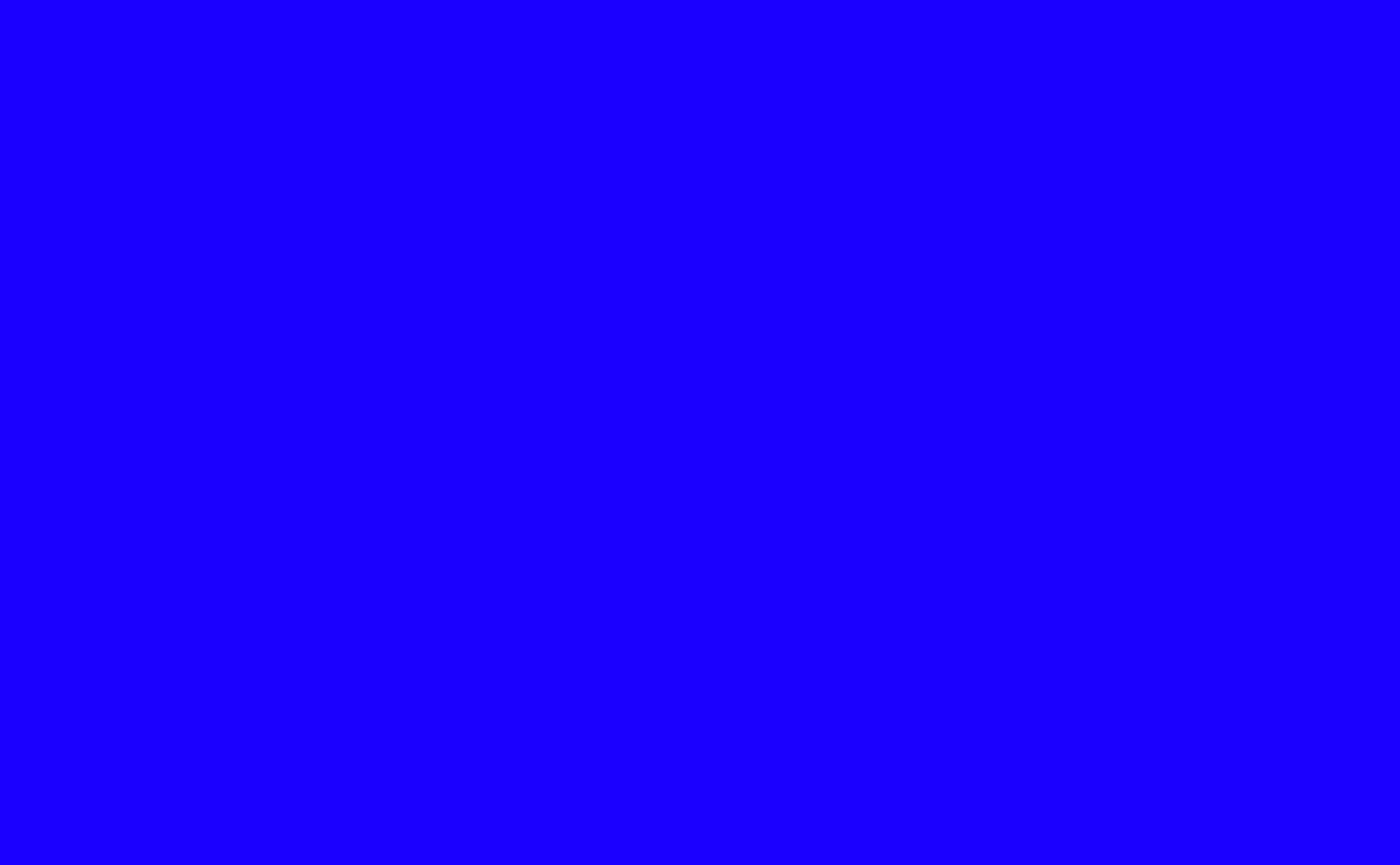

N_=np.int64(23)
[0.11 0.   1.  ]


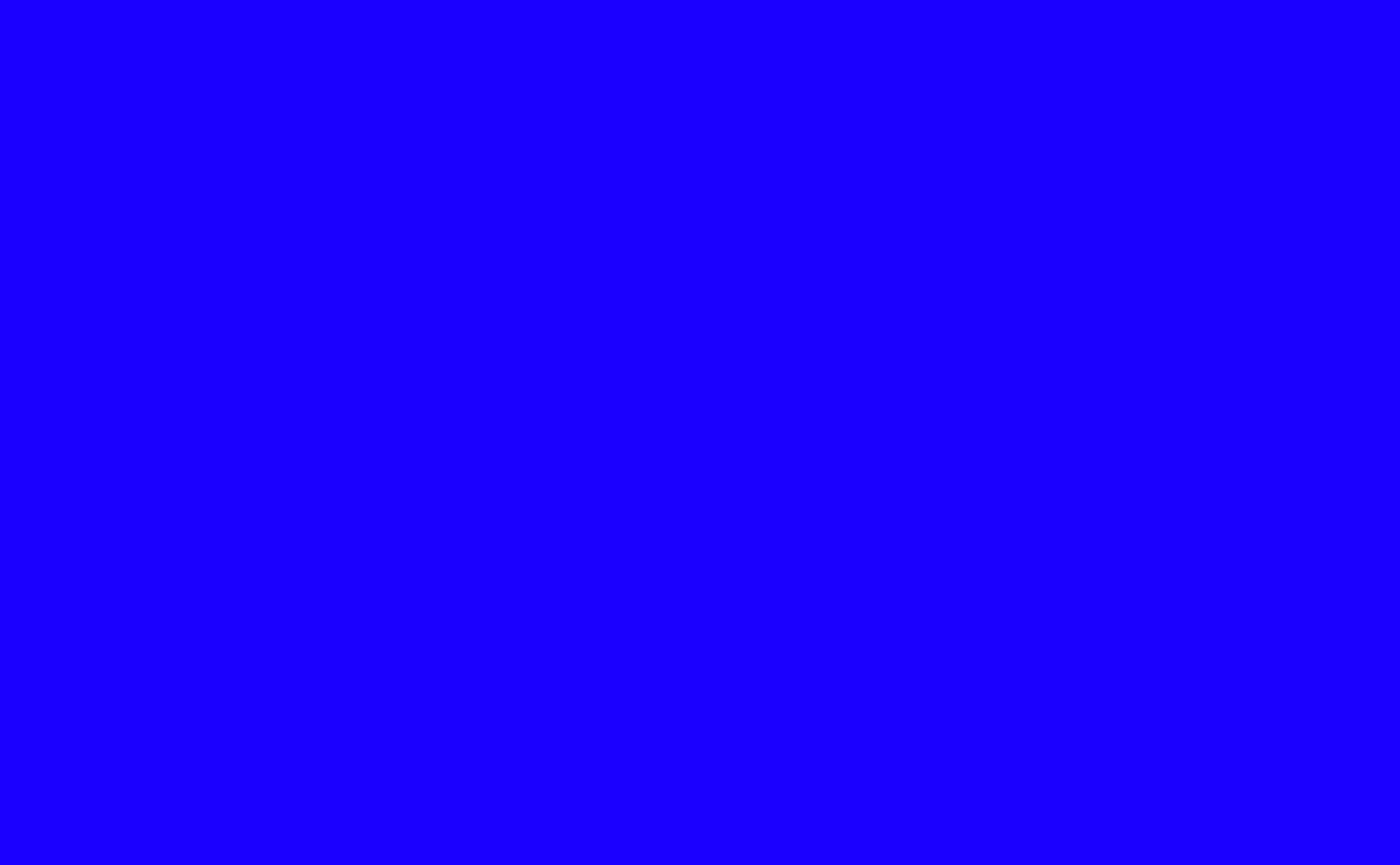

N_=np.int64(28)
[0.11 0.   1.  ]


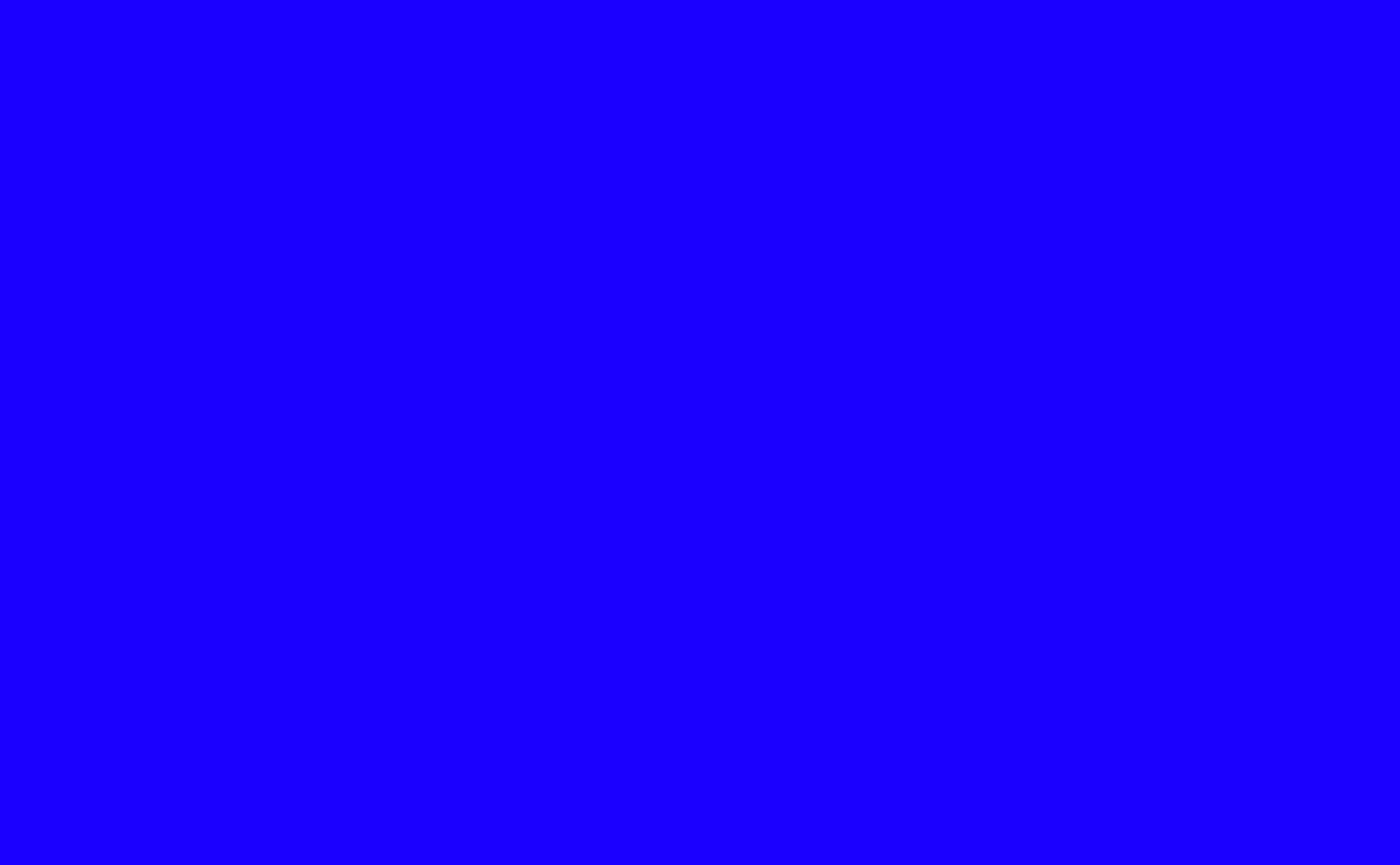

N_=np.int64(33)
[0.11 0.   1.  ]


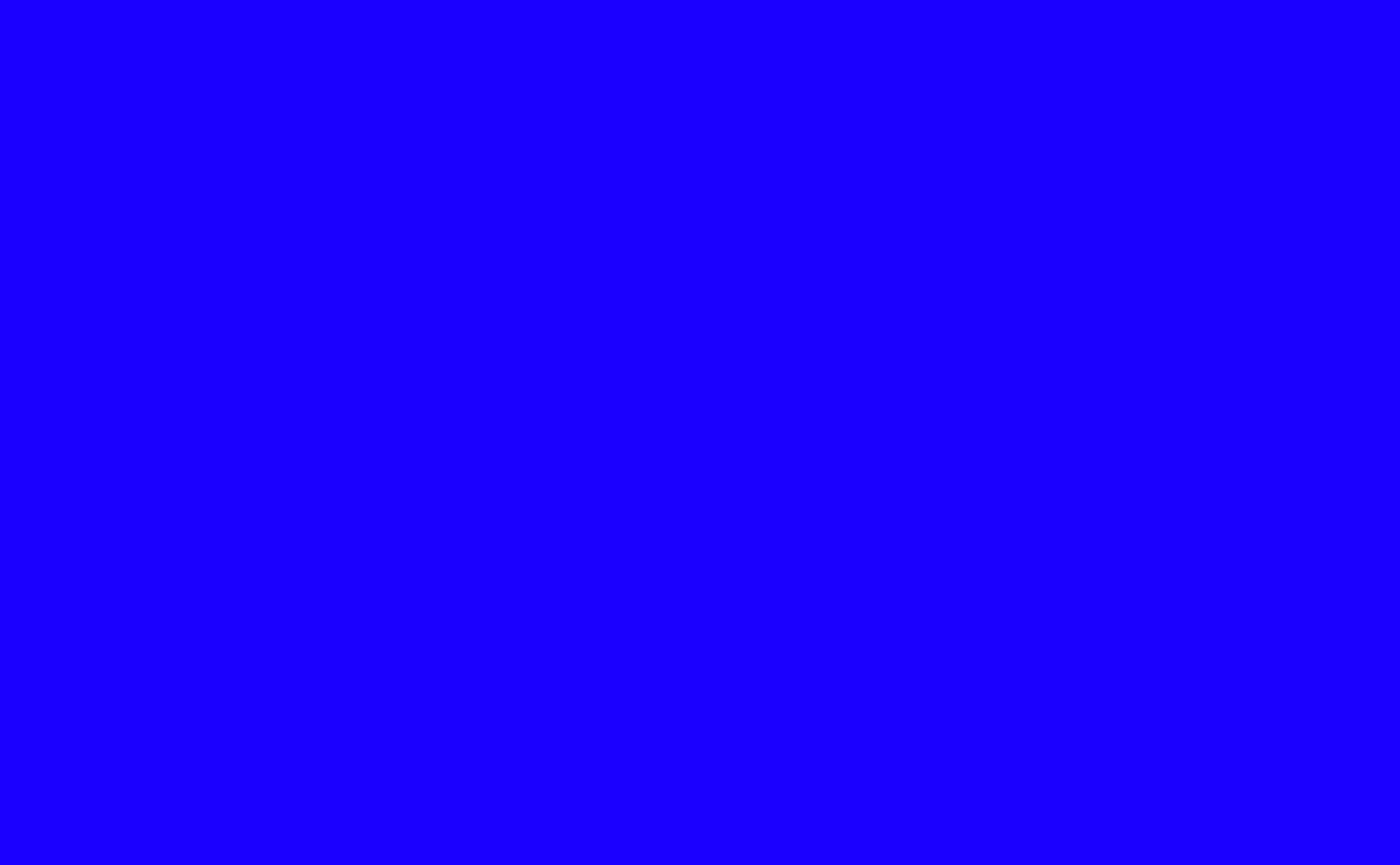

N_=np.int64(40)
[0.11 0.   1.  ]


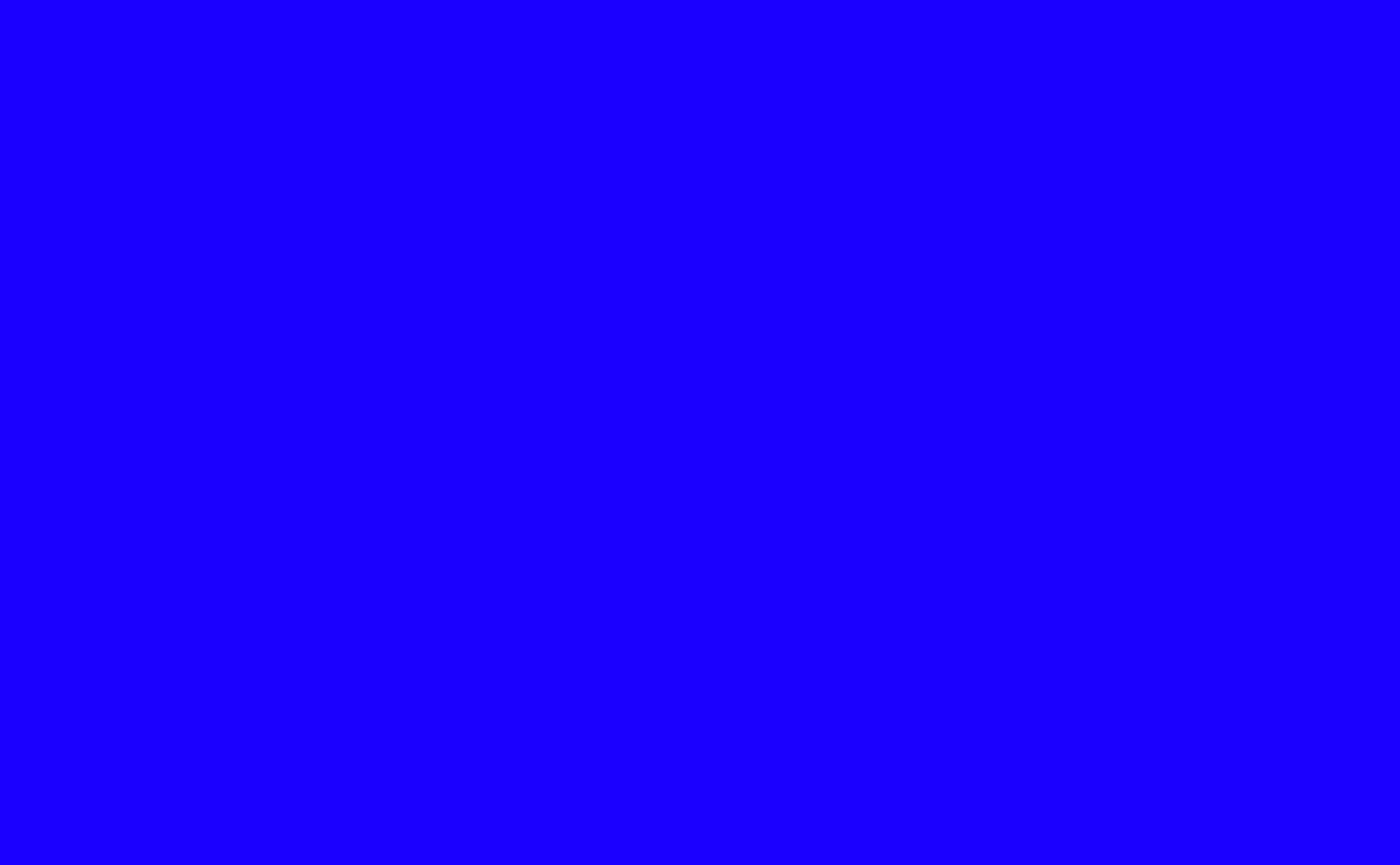

In [24]:
opts_ = opts.copy()
Ns = np.unique([int(k) for k in N_W * np.logspace(-1, 1, N_scan, base=2, endpoint=True)]).astype(int)
for N_ in Ns: 
    opts_.update(N_H=int(N_*N_height/N_width), N_W=N_)
    print(f'{N_=}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

### Scan Analysis: N_H and N_W (Grid Density)

First, this sweep changes lattice density, which is equivalent to changing the spatial frequency content of the pattern. Second, the code traverses density values and renders each configuration so that spacing-dependent perceptual transitions are explicit. Third, sparse spacing is usually readable everywhere, dense spacing can fuse in the periphery, and the most informative operating point is near the boundary where central segmentation remains available but peripheral parsing degrades through larger receptive-field pooling.

## shape exploration

shape_mode=circle, n_sides=6
[0.11 0.   1.  ]


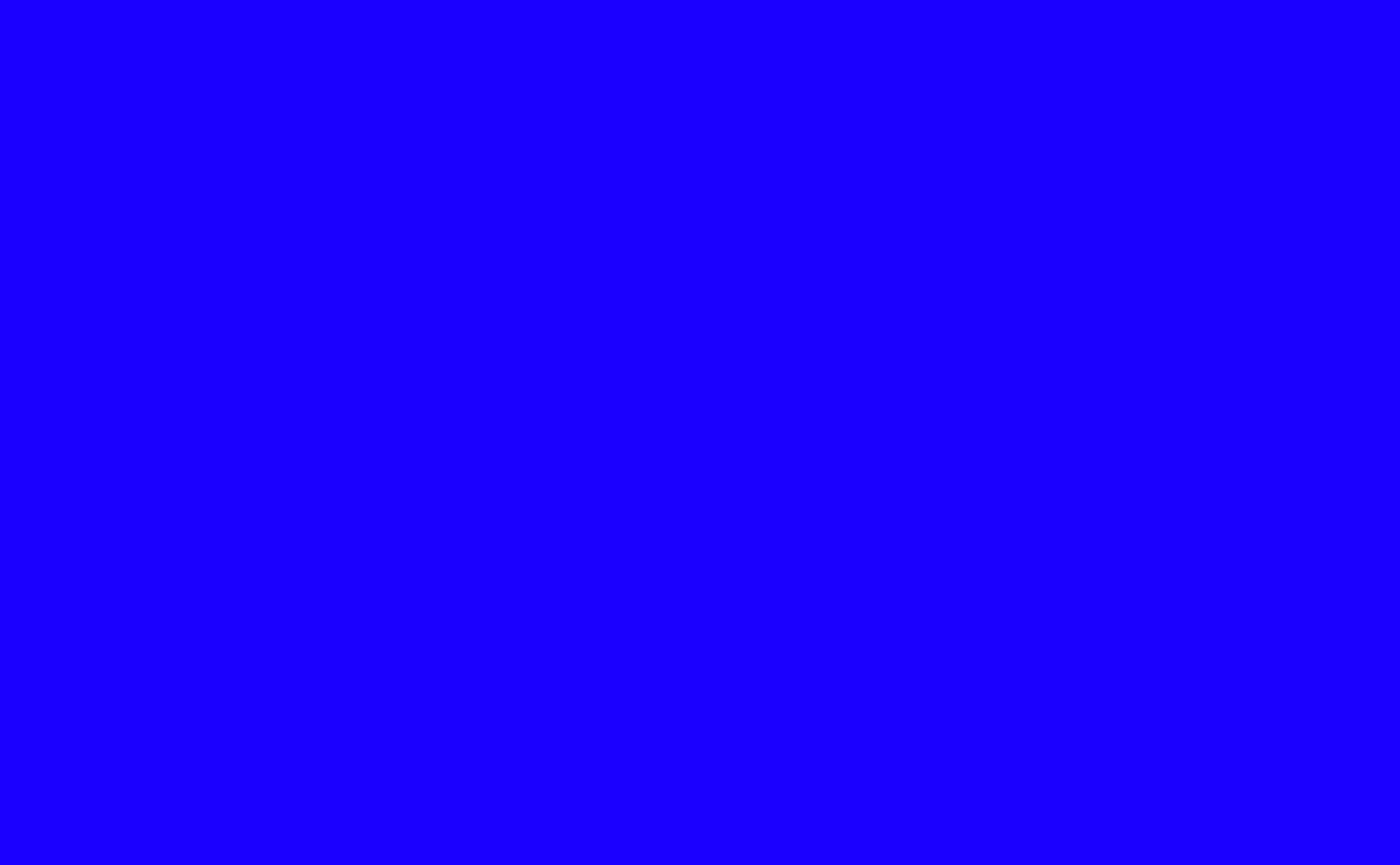

shape_mode=diagonal, n_sides=4
[0.11 0.   1.  ]


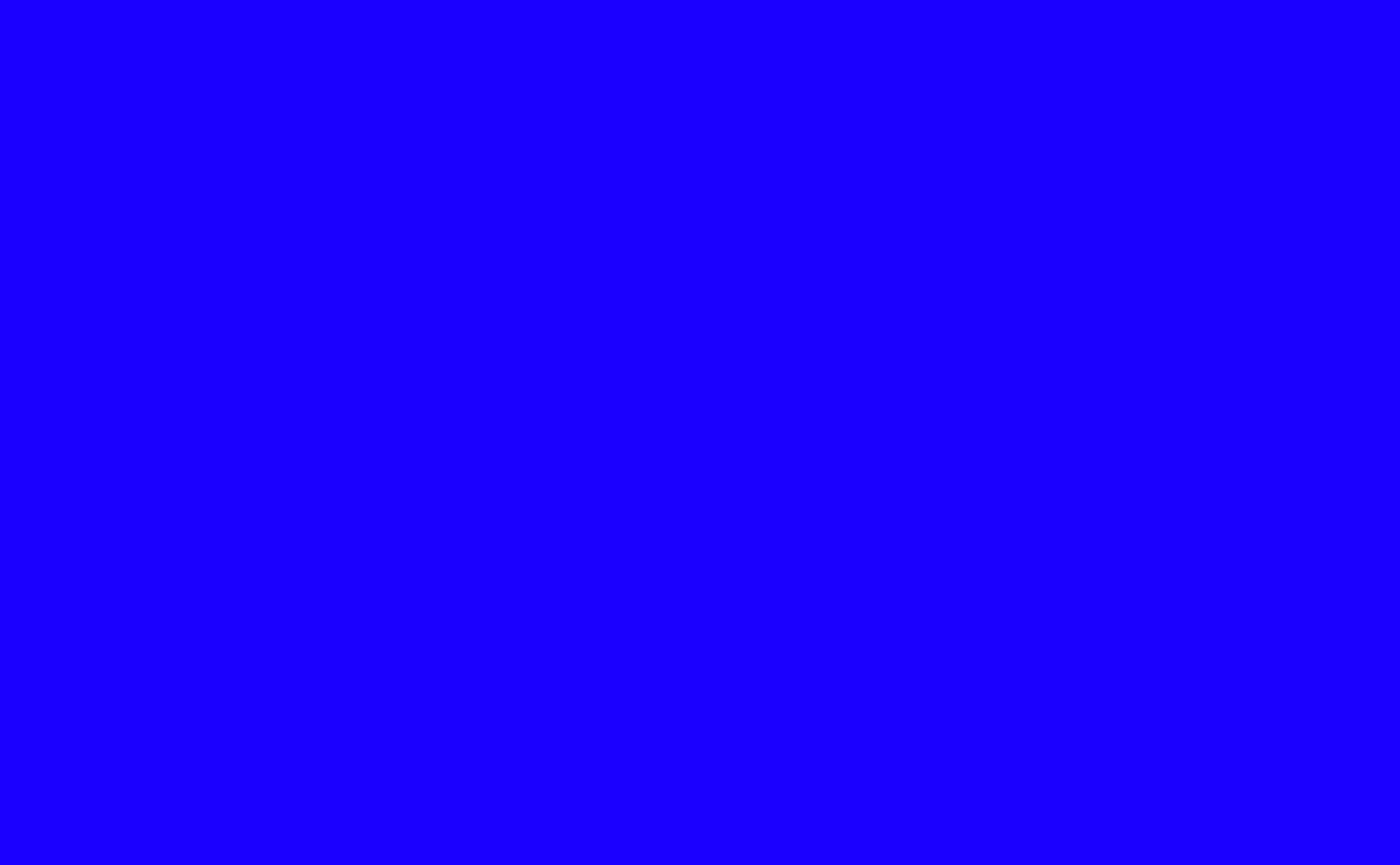

shape_mode=polygon, n_sides=3
[0.11 0.   1.  ]


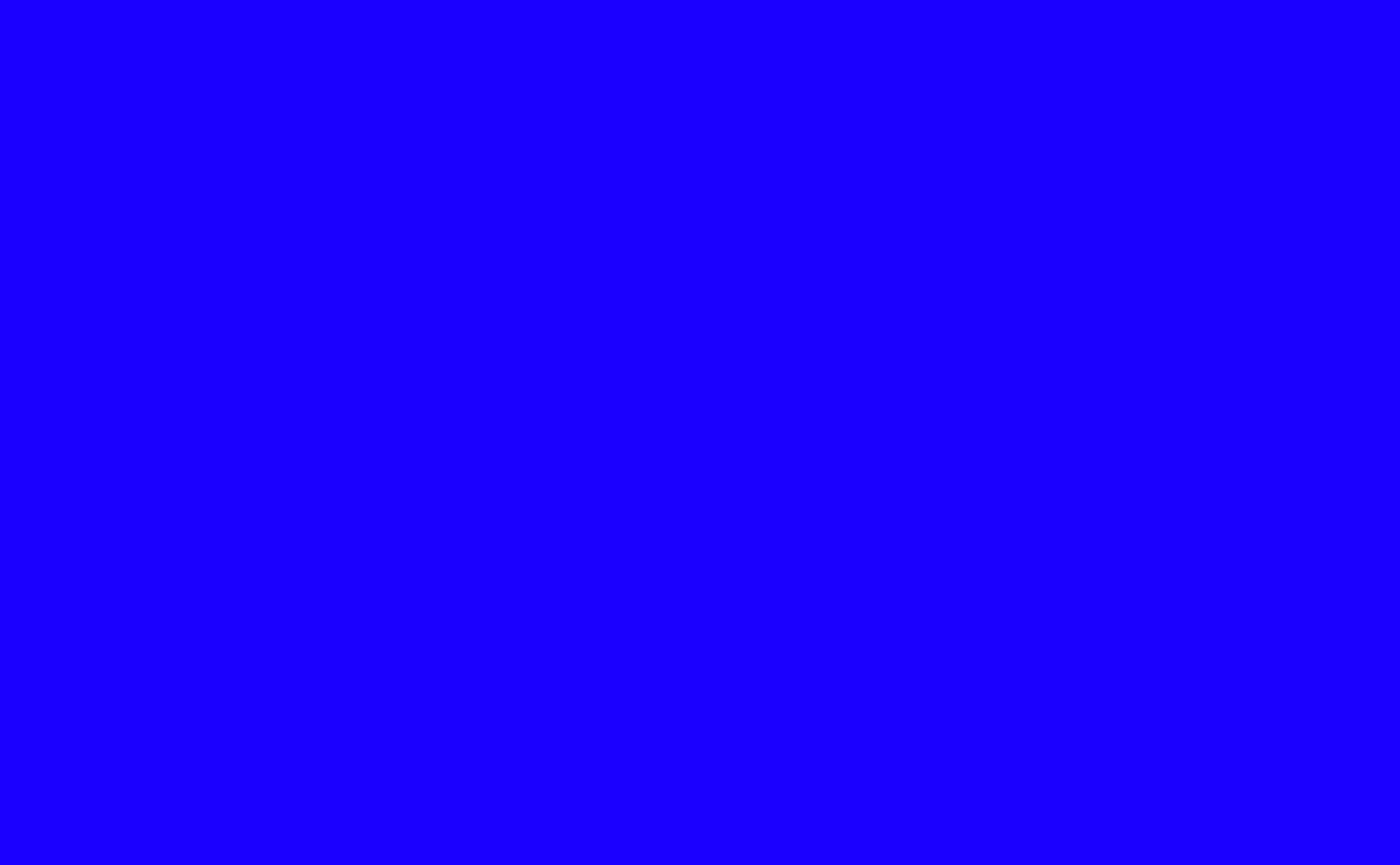

shape_mode=polygon, n_sides=4
[0.11 0.   1.  ]


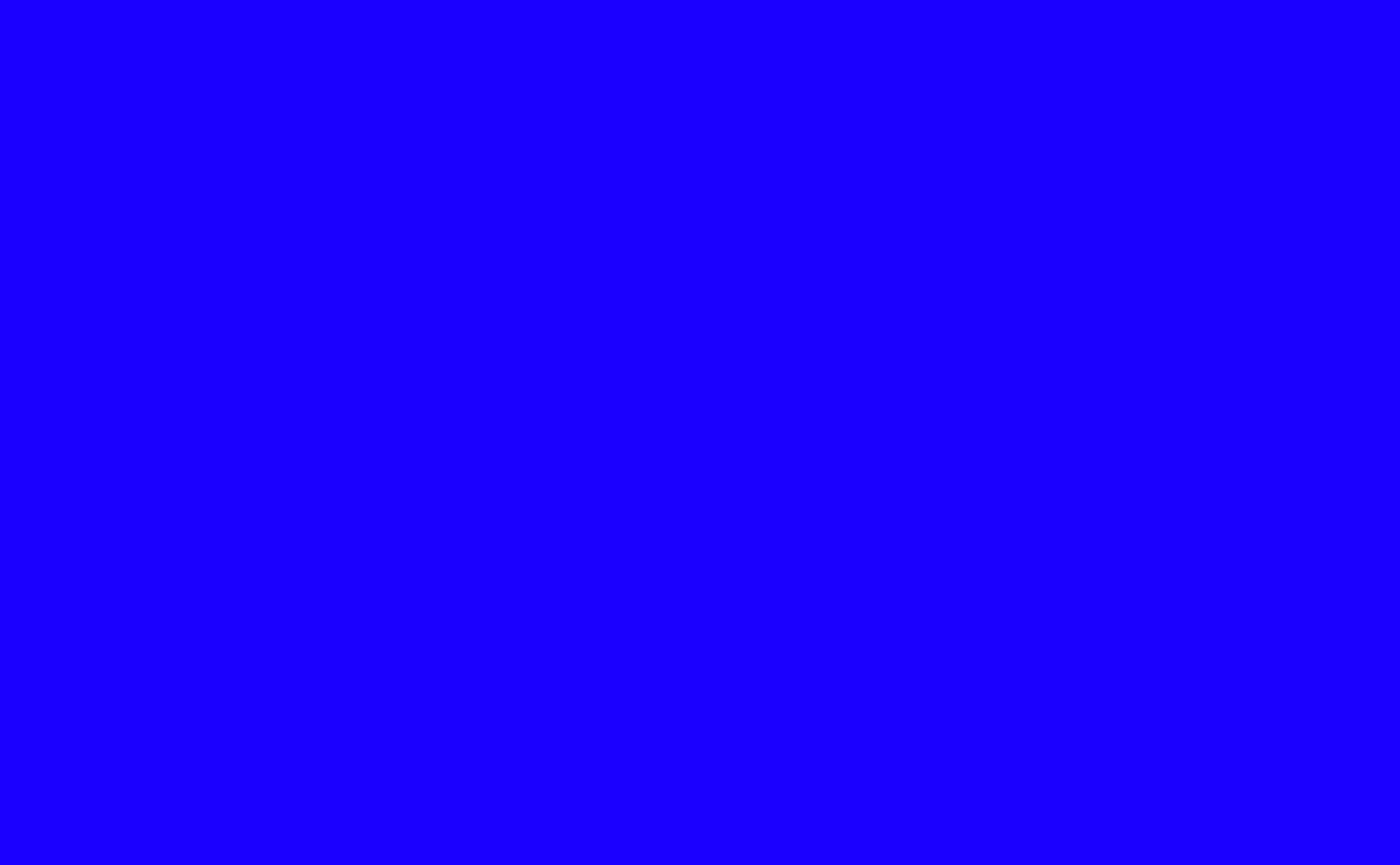

shape_mode=polygon, n_sides=5
[0.11 0.   1.  ]


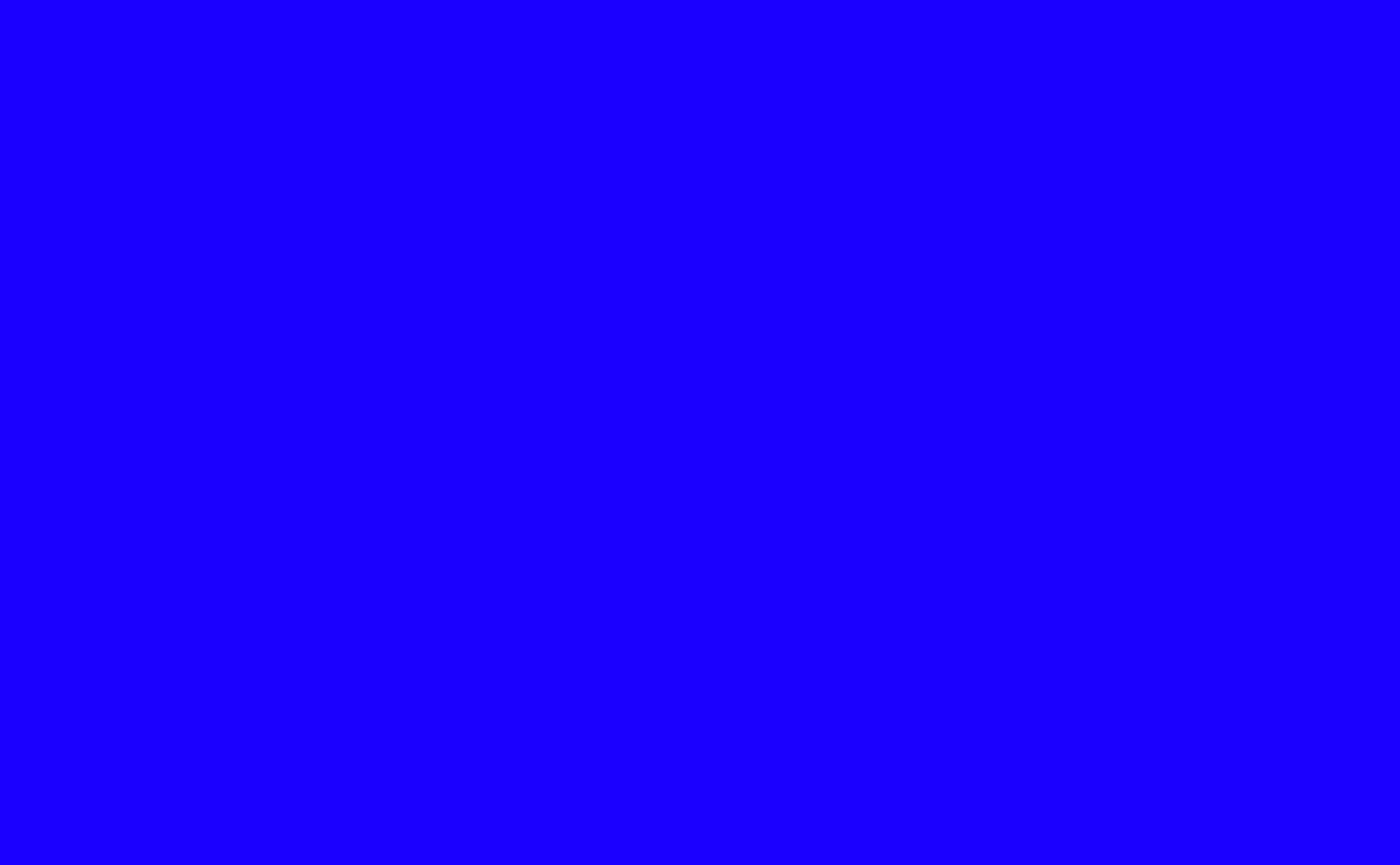

shape_mode=polygon, n_sides=6
[0.11 0.   1.  ]


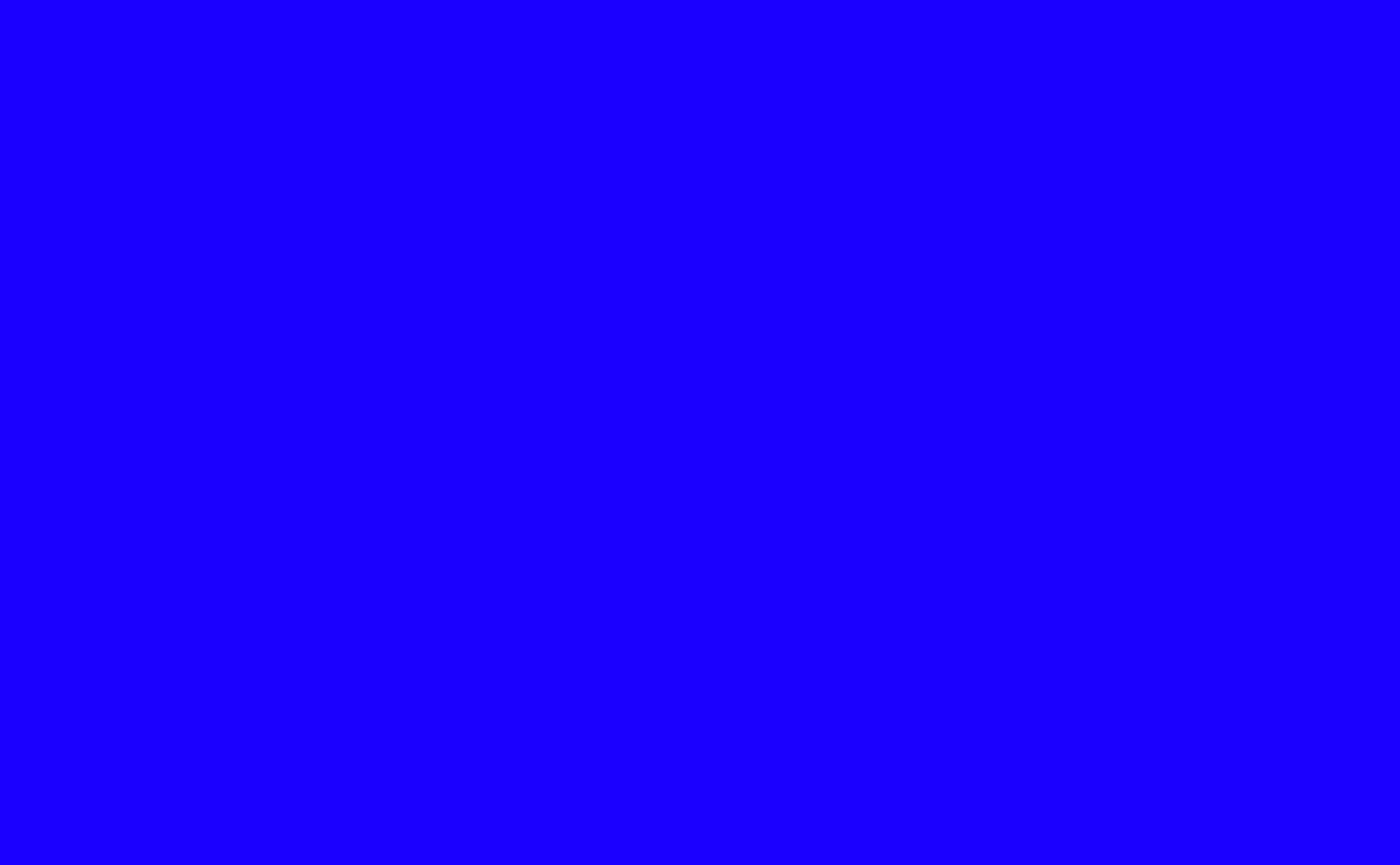

shape_mode=polygon, n_sides=8
[0.11 0.   1.  ]


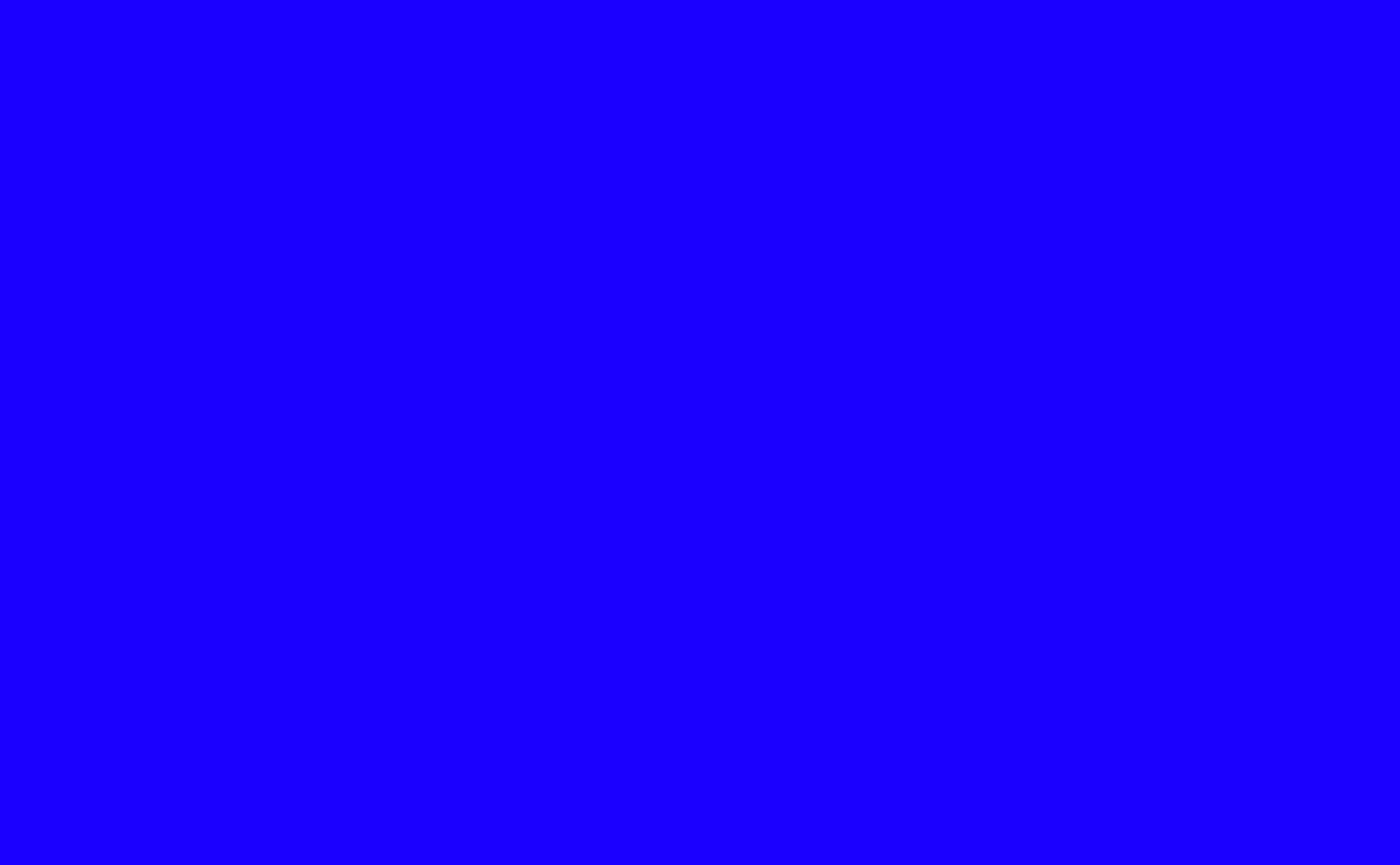

In [25]:
# Exploration of different shape families
opts_ = opts.copy()
# opts_.update(size_mag=.5, N_H=max(6, N_H//2), N_W=max(6, N_W//2))

shape_configs = [
    ('circle', 6),
    ('diagonal', 4),
    ('polygon', 3),
    ('polygon', 4),
    ('polygon', 5),
    ('polygon', 6),
    ('polygon', 8),
]

for shape_mode_, n_sides_ in shape_configs:
    opts_.update(shape_mode=shape_mode_, n_sides=n_sides_)
    print(f'shape_mode={shape_mode_}, n_sides={n_sides_}')

    @disp
    def draw(cr, N_height=N_height, N_width=N_width):
        cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: Shape Family

First, this sweep changes local contour class by alternating circles, diagonals, and polygons with different side counts. Second, the code enumerates shape configurations and displays one frame per configuration, enabling direct comparison of orientation and corner cues. Third, smoother contours generally reduce explicit local anchors, whereas angular shapes increase corner energy and orientation evidence, which can improve fixation-locked parsing but may also reduce peripheral ambiguity if the cues become too strong.

## Discussion and Conclusion

Across sweeps, the most effective stimuli are those that sit near a perceptual threshold where central segmentation is reliable and peripheral structure remains unstable. This operating regime is coherent with retinal physiology, because foveal and parafoveal cone-rich regions support fine chromatic and spatial discrimination, while rod-dominated peripheral regions rely on larger pooling and weaker color-resolved parsing.

In practical terms, the illusion is strongest when opacity, size, chromatic spread, and density are jointly tuned so that dots do not become either globally invisible or globally obvious. The macular scale, roughly comparable to a thumb at arm length, offers a useful perceptual anchor for interpreting where detailed structure should remain stable in the image.

The main methodological strength of this notebook is the one-factor-at-a-time sweep strategy combined with immediate visual output. The next experimental step is to quantify these observations with psychophysical measurements, for example by measuring detectability as a function of eccentricity and mapping the parameter region that maximizes fixation-dependent appearance changes.

## some book keeping for the notebook

In [26]:
%pwd

'/Users/laurentperrinet/sdrive_cnrs/blog/laurentperrinet.github.io_sciblog/posts'

In [27]:
%load_ext watermark
%watermark -i -h -m -v -p numpy,cairo  -r -g -b

Python implementation: CPython
Python version       : 3.13.14
IPython version      : 8.30.0

numpy: 2.5.1
cairo: unknown

Compiler    : Clang 21.0.0 (clang-2100.0.123.102)
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 10
Architecture: 64bit

Hostname: obiwan.local

Git hash: 4db0253e1b275c9764fa0704f6d0fe1b9b488152

Git repo: https://github.com/laurentperrinet/sciblog

Git branch: master

